In [1]:
using JuMP, HiGHS, CPLEX, Random, Plots, Gurobi, Dualization
using DataFrames
import Plots, Printf
import Distributions
import SparseArrays
using LinearAlgebra
using StatsPlots
using Distributions

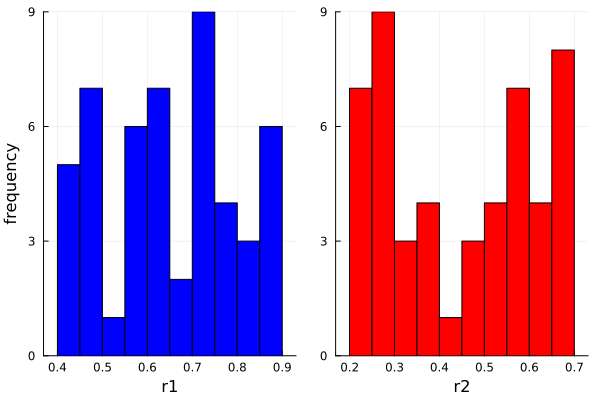

In [2]:
R1 = Distributions.Uniform(0.4, 0.9)
N = 50
r1 = sort!(rand(R1, N))

R2 = Distributions.Uniform(0.2, 0.7)
r2 = sort!(rand(R2, N))

# Create histograms
hist1 = histogram(r1, bins = 20, label = "", xlabel = "r1", ylabel = "frequency", color = :blue)
hist2 = histogram(r2, bins =20, label = "", xlabel = "r2", color = :red)

# Plot histograms
plot(hist1, hist2; layout = @layout([a b]))

In [3]:
# Data
O = 55
T = 2
M = 2
E = 2
Ph = 8
Comp = [0.33, 0.25, 0.1, 0.1, 0.05, 0.05, .02, 0.1] 
b= rand(25:115, O)
diagonal_values = ones(O) * 0
Rm = 200* rand(M, Ph)
# Generate random values for all elements
all_values = rand(2:10, O, O) 

# Create the final matrix
c = 4 * rand(1:3, O,E)
cap_h = rand(125:455, O) 
cap_z1 = rand(202:259, M)
cz1 = 500 * ones(M)
c1 = all_values
for i in 1:O
    c1[i, i] = diagonal_values[i]
end
c2 = 0.5 * rand(2:20, O, T) + rand(O,T)
c3 = 2*rand(2:20, O, M) + rand(O, M)
c4 = rand(4:10, T, M) + rand(T, M)
c5 = 10*rand(2:5, M, E) + rand(M, E)
c_Lf = 60
c_buy = 20*rand(3:8, M,Ph)
c_op = 5*rand(4:10, M,Ph)
Q = 10*rand(Uniform(0.9,1.0),Ph)
H = 2*rand(4:8, Ph)
D = 0.3
big_M = 10000
α = 0.4
ef= rand(0.6:0.01:0.8, N, M, Ph)
ef_max = zeros(1:Ph)
for p in 1:Ph
    ef_max[p] = (maximum(ef[:,:,p]))
end
r1_max = maximum(r1)
r2_max = maximum(r2)
cost_hub = rand(10205:12255, O)
Random.seed!(456)
r2 = rand(0.6:0.01:0.8, N, M)
r1 = rand(0.75:0.01:0.93, N, M) 
# r2 = rand(0.2:0.1:0.7, N, M)

50×2 Matrix{Float64}:
 0.8   0.91
 0.82  0.91
 0.75  0.79
 0.77  0.91
 0.89  0.87
 0.77  0.91
 0.9   0.87
 0.92  0.92
 0.93  0.81
 0.78  0.82
 0.84  0.75
 0.88  0.91
 0.78  0.87
 ⋮     
 0.91  0.84
 0.89  0.91
 0.83  0.76
 0.86  0.92
 0.78  0.77
 0.85  0.9
 0.76  0.84
 0.91  0.83
 0.86  0.77
 0.76  0.79
 0.79  0.93
 0.75  0.75

In [4]:
ratio = zeros(O)
for i in 1:O
    ratio[i] = (cost_hub[i] ./ cap_h[i])
end
sortperm(ratio)
function capacity_VI(cap_h)
    current_sum = 0
    selected_elements = []

    for i in sort(cap_h, rev = true) 
        push!(selected_elements, i)  
        current_sum += i  
        if current_sum >= sum(b) 
            break 
        end
    end

    return selected_elements, current_sum  
end
selected_elements, total_sum = capacity_VI(cap_h)
num = length(selected_elements)

10

In [5]:
ub = zeros(O)
for j in 1:O
    model = Model(HiGHS.Optimizer)
    set_silent(model)

    @variable(model, 0 <= UB[1:O, j] <= 1, Bin)
    
    @constraint(model, sum(UB[i, j] * b[i] for i in 1:O if i != j) <= (cap_h[j] - b[j]))
    
    @objective(model, Max, sum(sum(UB[i, j] for i in 1:O if i != j)))
    
    optimize!(model)
    ub[j] = sum(value(UB[i, j]) for i in 1:O)
end
ub

┌ Warning: Axis contains one element: 1. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[1]` instead of `1`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 2. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[2]` instead of `2`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 3. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[3]` instead of `3`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 4. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[4]` instead of `4`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\

55-element Vector{Float64}:
  6.0
  7.0
  3.0
  7.0
  8.0
  6.0
  8.0
  2.0
 11.0
  4.0
 10.0
  9.0
  3.0
  ⋮
  3.0
  2.0
 11.0
  4.0
 10.0
  8.0
  9.0
  4.0
  3.0
  6.0
  4.0
  9.0

In [11]:
model = JuMP.direct_model(Gurobi.Optimizer())
set_optimizer_attribute(model, "OutputFlag", 0)
set_time_limit_sec(model, 1800.0)
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Hqere and Now)
@variable(model, 0 <= x[1:O, 1:O] <=1, Bin)
@variable(model, f2[1:O, 1:T] >=0)
@variable(model, f3[1:O, 1:M] >=0)
@variable(model, f4[1:T, 1:M] >=0)
# @variable(model, z1[1:M], Bin)
# @variable(model, y[1:O], Bin)
@variable(model, ft[1:T] >=0)
@variable(model, fh[1:O] >=0)

@constraint(model, assgn[i in 1:O], sum(x[i, j] for j in 1:O) == 1)
@constraint(model, assgn2[i in 1:O, j in 1:O], x[i, j] <= x[j,j])
@constraint(model, cap[j in 1:O], sum(x[i, j] * b[i] for i in 1:O) <= cap_h[j]* x[j, j])
@constraint(model, flow_h_t_m[j in 1:O], sum(f2[j, t] for t in 1:T) + sum(f3[j, m] for m in 1:M) == 
        sum(x[i, j] * b[i] for i in 1:O))
@constraint(model, flow_t_a[t in 1:T], sum(f2[i, t] for i in 1:O) == sum(f4[t, m] for m in 1:M))

# List of Valid Inequalities

@constraint(model, hub_VI, sum(x[j, j] for j in 1:O) >= ceil(sum(b[i] for i in 1:O)/maximum(cap_h)))
# @constraint(model, hub_bin_VI, sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:O) - sum(x[j, j] for j in 1:O) <= ceil(O/5) -
    #ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)))
# @constraint(model, hub_res_VI, ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)) - sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:ceil(Int, O/5))
    #<= sum(x[j, j] for j in (ceil(Int, O/5)+1):O))
@constraint(model, hub_VIalt, sum(x[j, j] for j in 1:O) >= num)
# @constraint(model, hub_VI2, sum(cap_h[j] for j in 1:O) - maximum(cap_h) >= sum(b[i] * x[i, j] for i in 1:O for j in 1:O))
@constraint(model, arc_ub[j in 1:O], sum(x[i, j] for i in 1:O if i!=j) <= (ub[j]) * x[j, j])

# @constraint(model, x[1,2] + x[1, 10] + x[2, 1] + x[2,10] + x[10, 1] + x[10, 2] <= 1)


# @constraint(model, 2 * (x[4, 5] + x[5, 6] + x[6, 7]) + x[4, 8] + x[5, 8] + x[6, 8] + sum(x[8, j] for j in 1:O if j!=8) <= 3)
# @constraint(model, flow_smb[i in 1:O, j in 1:O], !x[i, j] --> {f[i, j] <= big_M})
# @constraint(model, flow_ts[t in 1:T], ft[t] == sum(f2[i, t] for i in 1:O))
# @constraint(model, flow_hs[j in 1:O], fh[j] == sum(f[i, j] for i in 1:O))
# @constraint(model, flow_assgn[i in 1:O], sum(f[i, j] for j in 1:O) == sum(b[i] * x[i, j] for j in 1:O))
# @constraint(model, flow_smb[i in 1:O, j in 1:O], f[i, j] <= b[i] * x[i,j])
# @constraint(model, hub_VI_try[i in 1: floor(Int, O/5), j in ceil(Int, O/5):O], x[i, j] + x[j, j] <= 2)

#source separated variable (project purpose)
# @variable(model, 0 <= z[1:O, 1:E] <=1, Bin)

# Second stage variable (See and follow)
@variable(model, 0 <= w1[1:N, 1:M, 1:Ph]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= s1[1:N, 1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)

#Recourse Constraints(for hub)

# @constraint(model, d2[n in 1:N, m in 1:M], -w1[n, m, 1] >= -sum(f3[j,m] for j in 1:O)*r1[n, m] - sum(f4[j,m] for j in 1:T)*r2[n, m])
@constraint(model, d1[n in 1:N, m in 1:M], w1[n, m, 1] == sum(f3[i, m] for i in 1:O) + sum(f4[i, m] for i in 1:T) -sum(s1[n, m, e, 1] for e in 1:E))
@constraint(model, d2[n in 1:N, m in 1:M, p in 2:Ph], w1[n, m, p] == w1[n,m,p-1] -sum(s1[n, m, e, p] for e in 1:E))
# @constraint(model, d3[n in 1:N, m in 1:M, j in 1:E, p in 1:Ph], s1[n, m, j, p] <= big_M * y1[n, m, j])
# @constraint(model, d5[n in 1:N, m in 1:M, p in 1:Ph], sum(y1[n, m, j, p] for j in 1:E) <= 1)
@constraint(model, d3[n in 1:N, m in 1:M, p in 1:Ph], sum(s1[n, m, e, p] for e in 1:E)  <= 
    (sum(f3[j,m] for j in 1:O) *r1[n, m]  + sum(f4[j,m] for j in 1:T) *r2[n, m]) *Comp[p]*ef[n, m, p])
# @constraint(model, d5[n in 1:N, e in 1:E-1, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M)- sum(s1[n, m, e+1, p] for m in 1:M)  <=0)
@constraint(model, d4[n in 1:N, e in 1:E, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M) >= D * Comp[p] * sum(b[i] for i in 1:O) * (1/E))

MRF_cost = c_Lf * (sum(w1[n,m, Ph] for n in 1:N for m in 1:M))
spoke_hub = sum(c1[i, j] * x[i, j] * b[i] for i in 1:O for j in 1:O)
hub_transfer = sum(c2[i, j] * f2[i, j] * α for i in 1:O for j in 1:T)
hub_mrf = sum(c3[i, j] * f3[i, j] for i in 1:O for j in 1:M)
transfer_mrf = sum(c4[i, j] * f4[i, j] for i in 1:T for j in 1:M)
Hub_cap_cost = sum(cost_hub[j] * x[j, j] for j in 1:O) 

first_stage =  spoke_hub +  hub_transfer + hub_mrf + transfer_mrf + Hub_cap_cost

# source_hub_cost = sum(c1[i, j] * x[j, j] for i in 1:O for j in 1:O if i!=j)

# revenue = sum(Rm[m, p] * s1[n, m, j, p] for n in 1:N for m in 1:M for j in 1:E for p in 1:Ph)
@objective(model, Min, first_stage + 1/(N) * (MRF_cost))
# unset_binary.(x)
optimize!(model)
gurobi_runtime = solve_time(model)
println("runtime: ", gurobi_runtime)
objective_value(model)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-18
runtime: 2162.680000066757


252993.3012157519

In [12]:
for i in 1:O
    for j in 1:O
        if value.(x[i, j]) >0
            println("$i, $j: ", value.(x[i, j]))
        end
    end
end
value.(MRF_cost)

1, 25: 1.0
2, 12: 1.0
3, 11: 1.0
4, 37: 1.0
5, 5: 1.0
6, 12: 1.0
7, 9: 1.0
8, 37: 1.0
9, 9: 1.0
10, 22: 1.0
11, 11: 1.0
12, 12: 1.0
13, 5: 1.0
14, 12: 1.0
15, 11: 1.0
16, 37: 1.0
17, 50: 1.0
18, 22: 1.0
19, 12: 1.0
20, 20: 1.0
21, 5: 1.0
22, 22: 1.0
23, 25: 1.0
24, 37: 1.0
25, 25: 1.0
26, 25: 1.0
27, 5: 1.0
28, 25: 1.0
29, 48: 1.0
30, 22: 1.0
31, 11: 1.0
32, 12: 1.0
33, 9: 1.0
34, 48: 1.0
35, 20: 1.0
36, 5: 1.0
37, 37: 1.0
38, 48: 1.0
39, 50: 1.0
40, 9: 1.0
41, 48: 1.0
42, 22: 1.0
43, 25: 1.0
44, 37: 1.0
45, 50: 1.0
46, 25: 1.0
47, 50: 1.0
48, 48: 1.0
49, 9: 1.0
50, 50: 1.0
51, 9: 1.0
52, 11: 1.0
53, 20: 1.0
54, 20: 1.0
55, 48: 1.0


5.39589511434e6

In [66]:
for p in Ph:Ph
    println(sum(value.(w1[1,:,p])))
end

348.73727600000007


In [ ]:
set_optimizer_attribute(model, "CliqueCuts", 0)
set_optimizer_attribute(model, "CoverCuts", 0)
set_optimizer_attribute(model, "RLTCuts", 0)
set_optimizer_attribute(model, "FlowCoverCuts", 0)
set_optimizer_attribute(model, "MIRCuts", 0)
set_optimizer_attribute(model, "StrongCGCuts", 0)
set_optimizer_attribute(model, "GUBcoverCuts", 0)

In [ ]:
using JuMP, Dualization
undo = relax_integrality(model)
dm = dualize(model; dual_names = DualNames("", ""))
print(dm)

**Decomposition Algorithm**

In [17]:
# Big_V = [2197.2110999999995, 2293.9376999999995, 2015.1374999999994, 2331.8696999999993, 2031.2585999999992]
Big_V = zeros(N) 
mm = JuMP.direct_model(Gurobi.Optimizer())
set_time_limit_sec(mm, 1800.0)
set_silent(mm)
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Here and Now)

@variable(mm, θ[1:N]>=-100)

@variable(mm, 0 <= x[1:O, 1:O] <=1, Bin)
@variable(mm, f2[1:O, 1:T] >=0)
@variable(mm, f3[1:O, 1:M] >=0)
@variable(mm, f4[1:T, 1:M] >=0)
# @variable(model, z1[1:M], Bin)
# @variable(model, y[1:O], Bin)
@variable(mm, ft[1:T] >=0)
@variable(mm, fh[1:O] >=0)

@constraint(mm, lifting_VI[n in 1:N],  θ[n] >= c_Lf * (sum(b) - sum(b) * max(r1_max, r2_max)* sum(Comp[p] * ef_max[p] for p in 1:Ph))) 

@constraint(mm, assgn[i in 1:O], sum(x[i, j] for j in 1:O) == 1)

@constraint(mm, assgn2[i in 1:O, j in 1:O], x[i, j] <= x[j,j])
@constraint(mm, cap[j in 1:O], sum(x[i, j] * b[i] for i in 1:O) <= cap_h[j] * x[j, j])
@constraint(mm, flow_h_t_m[j in 1:O], sum(f2[j, t] for t in 1:T) + sum(f3[j, m] for m in 1:M) == 
        sum(x[i, j] * b[i] for i in 1:O))
@constraint(mm, flow_t_a[t in 1:T], sum(f2[i, t] for i in 1:O) == sum(f4[t, m] for m in 1:M))

# List of Valid Inequalities

@constraint(mm, hub_VI, sum(x[j, j] for j in 1:O) >= ceil(sum(b[i] for i in 1:O)/maximum(cap_h)))
@constraint(mm, hub_bin_VI, sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:O) - sum(x[j, j] for j in 1:O) <= ceil(O/5) -
    ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)))
@constraint(mm, hub_res_VI, ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)) - sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:ceil(Int, O/5))
    <= sum(x[j, j] for j in (ceil(Int, O/5)+1):O))
@constraint(mm, hub_VIalt, sum(x[j, j] for j in 1:O) >= num)
@constraint(mm, hub_VI2, sum(cap_h[j] for j in 1:O) - maximum(cap_h) >= sum(b[i] * x[i, j] for i in 1:O for j in 1:O))
@constraint(mm, arc_ub[j in 1:O], sum(x[i, j] for i in 1:O if i!=j) <= (ub[j]) * x[j, j])

# @constraint(model, x[1,2] + x[1, 10] + x[2, 1] + x[2,10] + x[10, 1] + x[10, 2] <= 1)


# @constraint(model, 2 * (x[4, 5] + x[5, 6] + x[6, 7]) + x[4, 8] + x[5, 8] + x[6, 8] + sum(x[8, j] for j in 1:O if j!=8) <= 3)
# @constraint(model, flow_smb[i in 1:O, j in 1:O], !x[i, j] --> {f[i, j] <= big_M})
# @constraint(model, flow_ts[t in 1:T], ft[t] == sum(f2[i, t] for i in 1:O))
# @constraint(model, flow_hs[j in 1:O], fh[j] == sum(f[i, j] for i in 1:O))
# @constraint(model, flow_assgn[i in 1:O], sum(f[i, j] for j in 1:O) == sum(b[i] * x[i, j] for j in 1:O))
# @constraint(model, flow_smb[i in 1:O, j in 1:O], f[i, j] <= b[i] * x[i,j])
# @constraint(model, hub_VI_try[i in 1: floor(Int, O/5), j in ceil(Int, O/5):O], x[i, j] + x[j, j] <= 2)


spoke_hub = sum(c1[i, j] * x[i, j] * b[i] for i in 1:O for j in 1:O)
hub_transfer = sum(c2[i, j] * f2[i, j] for i in 1:O for j in 1:T)
hub_mrf = sum(c3[i, j] * f3[i, j] for i in 1:O for j in 1:M)
transfer_mrf = sum(c4[i, j] * f4[i, j] for i in 1:T for j in 1:M)
Hub_cap_cost = sum(cost_hub[j] * x[j, j] for j in 1:O) 

first_stage =  spoke_hub +  hub_transfer + hub_mrf + transfer_mrf + Hub_cap_cost
# unset_binary.(x)
@objective(mm, Min, first_stage + (1/N) * sum(θ[n] for n in 1:N))
# optimize!(mm)
# objective_value(mm)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-18
Set parameter TimeLimit to value 1800


64 x[1,2] + 288 x[1,3] + 128 x[1,4] + 288 x[1,5] + 224 x[1,6] + 224 x[1,7] + 288 x[1,8] + 96 x[1,9] + 160 x[1,10] + 320 x[1,11] + 224 x[1,12] + 96 x[1,13] + 320 x[1,14] + 64 x[1,15] + 64 x[1,16] + 288 x[1,17] + 320 x[1,18] + 64 x[1,19] + 288 x[1,20] + 160 x[1,21] + 192 x[1,22] + 64 x[1,23] + 128 x[1,24] + 64 x[1,25] + 160 x[1,26] + 288 x[1,27] + 192 x[1,28] + 128 x[1,29] + 192 x[1,30] + 128 x[1,31] + [[...3239 terms omitted...]] + 0.02 θ[21] + 0.02 θ[22] + 0.02 θ[23] + 0.02 θ[24] + 0.02 θ[25] + 0.02 θ[26] + 0.02 θ[27] + 0.02 θ[28] + 0.02 θ[29] + 0.02 θ[30] + 0.02 θ[31] + 0.02 θ[32] + 0.02 θ[33] + 0.02 θ[34] + 0.02 θ[35] + 0.02 θ[36] + 0.02 θ[37] + 0.02 θ[38] + 0.02 θ[39] + 0.02 θ[40] + 0.02 θ[41] + 0.02 θ[42] + 0.02 θ[43] + 0.02 θ[44] + 0.02 θ[45] + 0.02 θ[46] + 0.02 θ[47] + 0.02 θ[48] + 0.02 θ[49] + 0.02 θ[50]

In [18]:
using HiGHS
function solve_subproblem(f3, f4, u)
    sm = direct_model(CPLEX.Optimizer(CPLEX.Env()))
    # set_optimizer_attribute(sm, "OutputFlag", 0)
    # set_attribute(sm, "presolve", "off")
    set_silent(sm)
    @variable(sm, 0 <= w1[1:M, 1:Ph]) # continuous_Recourse variable(effective throughput)
    @variable(sm, 0 <= s1[1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)

    #con1 = @constraint(sm, d1[m in 1:M], w1[m, 1] == sum(f3[j,m] for j in 1:O) *r1[u, m]  + sum(f4[j,m] for j in 1:T) *r2[u, m])
    con1 = @constraint(sm, d1[m in 1:M, p in 1:Ph], sum(s1[m, e, p] for e in 1:E) <= 
        (sum(f3[j,m] for j in 1:O) * r1[u, m]  + sum(f4[j,m] for j in 1:T) * r2[u, m]) * Comp[p] * ef[u, m, p])
    con2 = @constraint(sm, d2[m in 1:M], -w1[m, 1] <= -sum(f3[i, m] for i in 1:O) - sum(f4[i, m] for i in 1:T) + sum(s1[m, e, 1] for e in 1:E))
    # con3 = @constraint(sm, d3[m in 1:M, j in 1:E, p in 1:Ph], s1[m, j, p] <= big_M * y1[m, j])
    # con4 = @constraint(sm, d4[m in 1:M, j in 1:E], sum(s1[m, j, p] for p in 1:Ph) <= big_M * y1[m, j])
    con3 = @constraint(sm, d3[m in 1:M, p in 2:Ph], w1[m, p] == w1[m,p-1] -sum(s1[m, e, p] for e in 1:E))
    # conb = @constraint(sm, db[m in 1:M, j in 1:E], y1[m, j] <= 1)
    con4 = @constraint(sm, d4[e in 1:E, p in 1:Ph], -sum(s1[m, e, p] for m in 1:M) <= -D * Comp[p] * sum(b[i] for i in 1:O) * (1/E))

    MRF_cost = c_Lf * (sum(w1[m, Ph] for m in 1:M))
    @objective(sm, Min, MRF_cost)
    optimize!(sm)
    if is_solved_and_feasible(sm; dual = true)
        return (is_feasible = true, obj = objective_value(sm), 
            w1 = value.(w1), s1 = value.(s1), π1 = dual.(con1), π2 = dual.(con2), π3 = dual.(con3), π4 = dual.(con4))
    end
    return (is_feasible = false, v = dual_objective_value(sm),
          u1 = dual.(con1), u2 = dual.(con2), u3 = dual.(con3), u4 = dual.(con4)) # u4 = dual.(con4)
end
function print_iteration(k, args...)
            f(x) = Printf.@sprintf("%12.4e", x)
            println(lpad(k, 9), " ", join(f.(args), " "))
            return
end
function store_results_to_csv(filename, O, T, M, E, N, gurobi_runtime, Multicut_runtime, Multicut_Nsp, Incremental_runtime, Incremental_Nsp, S)

    OTMEN = "$O-$T-$M-$E-$N"
    result = DataFrame(Instance=OTMEN, gurobi_runtime=gurobi_runtime, Multicut_runtime =Multicut_runtime, Multicut_Nsp = Multicut_Nsp, 
        Incremental_runtime = Incremental_runtime, Incremental_Nsp = Incremental_Nsp, Scenario=N)
    
    if !isfile(filename)

        CSV.write(filename, result)
    else
        # Append data
        CSV.write(filename, result, append=true)
    end
end

store_results_to_csv (generic function with 1 method)

In [19]:
ABSOLUTE_OPTIMALITY_GAP = 1e-6
sp_solves = 0
gap = []
# Initialize variables
Flag_Status = true
π1_history = []
π2_history = []
π4_history = []
revisited_u = Set()
function my_callback(cb_data)
    status = callback_node_status(cb_data, mm)

    # Only add constraints if the node is an integer solution
    if status != MOI.CALLBACK_NODE_STATUS_INTEGER
        return
    end

    # Read values from the callback data
    x_k = callback_value.(cb_data, x)
    f2_k = callback_value.(cb_data, f2)
    f3_k = callback_value.(cb_data, f3)
    f4_k = callback_value.(cb_data, f4)
    θ_k = callback_value.(cb_data, θ)
    first_stage_k = callback_value.(cb_data, first_stage)
    lower_bound = (1 / N) * sum(θ_k)

    global k

    add_constraint_needed = false  # Flag

    for u in 1:min(k, N)  
        
            ret = solve_subproblem(f3_k, f4_k, u)
            upper_bound = ret.obj
            ac_lb = θ_k[u]
            gap = abs(upper_bound - ac_lb)
            # print_iteration(u, ret.obj, ac_lb, gap)

            if ret.obj - θ_k[u] >= ABSOLUTE_OPTIMALITY_GAP
                if u in revisited_u  
                    delete!(revisited_u, u) 
                    println("$u needs further cuts")
                end
                global sp_solves += 1
                cut = @build_constraint(
                    θ[u] >= sum(ret.π1[m, p] * Comp[p] * ef[u, m, p] * 
                    (sum(f3[i, m] for i in 1:O) * r1[u, m]  + sum(f4[i, m] for i in 1:T) * r2[u, m]) for m in 1:M for p in 1:Ph) -
                    sum(ret.π2[m] * sum(f3[i, m] for i in 1:O) for m in 1:M) -
                    sum(ret.π2[m] * sum(f4[i, m] for i in 1:T) for m in 1:M)  -
                    D * (1 / E) * sum(b[i] for i in 1:O) * sum(ret.π4[e, p] * Comp[p] for p in 1:Ph for e in 1:E)
                )
                @info("add $sp_solves cut for $u")
                MOI.submit(mm, MOI.LazyConstraint(cb_data), cut)
            else
                # @info("$u reach gap")
                push!(revisited_u, u)
            end
    end

    if k <= N
            @info("add next sample subset")
            k += R
    end

    # If all u have met the gap condition
    return
end

set_attribute(mm, MOI.LazyConstraintCallback(), my_callback)

In [20]:
println("u   Upper Bound  Lower Bound          Gap")
k = N # Initial value of k (number of scenarios to check)
R = 100
optimize!(mm)
Multicut_runtime = solve_time(mm)
Multicut_Nsp = sp_solves
println("total inner loop iterations required: $Multicut_Nsp")
println("total CPU runtime: ", Multicut_runtime)
global k = 0
objective_value(mm)

u   Upper Bound  Lower Bound          Gap


[ Info: add 1 cut for 1
[ Info: add 2 cut for 2
[ Info: add 3 cut for 3
[ Info: add 4 cut for 4
[ Info: add 5 cut for 5
[ Info: add 6 cut for 6
[ Info: add 7 cut for 7
[ Info: add 8 cut for 8
[ Info: add 9 cut for 9
[ Info: add 10 cut for 10
[ Info: add 11 cut for 11
[ Info: add 12 cut for 12
[ Info: add 13 cut for 13
[ Info: add 14 cut for 14
[ Info: add 15 cut for 15
[ Info: add 16 cut for 16
[ Info: add 17 cut for 17
[ Info: add 18 cut for 18
[ Info: add 19 cut for 19
[ Info: add 20 cut for 20
[ Info: add 21 cut for 21
[ Info: add 22 cut for 22
[ Info: add 23 cut for 23
[ Info: add 24 cut for 24
[ Info: add 25 cut for 25
[ Info: add 26 cut for 26
[ Info: add 27 cut for 27
[ Info: add 28 cut for 28
[ Info: add 29 cut for 29
[ Info: add 30 cut for 30
[ Info: add 31 cut for 31
[ Info: add 32 cut for 32
[ Info: add 33 cut for 33
[ Info: add 34 cut for 34
[ Info: add 35 cut for 35
[ Info: add 36 cut for 36
[ Info: add 37 cut for 37
[ Info: add 38 cut for 38
[ Info: add 39 cut for 39
[ In

total inner loop iterations required: 50
total CPU runtime: 263.5720000267029


254709.50618692092

In [16]:
println("Scenario  Upper Bound    Lower Bound          Gap")
k = 8 # Initial value of k (number of scenarios for Incremental Benders)
R = 8
optimize!(mm)
Incremental_runtime = solve_time(mm)
Incremental_Nsp = sp_solves
println("total inner loop iterations required: $Incremental_Nsp")
println("total CPU runtime: ", Incremental_runtime)
global k = 0
objective_value(mm)

Scenario  Upper Bound    Lower Bound          Gap


[ Info: add 1 cut for 1
[ Info: add 2 cut for 2
[ Info: add 3 cut for 3
[ Info: add 4 cut for 4
[ Info: add 5 cut for 5
[ Info: add 6 cut for 6
[ Info: add 7 cut for 7
[ Info: add 8 cut for 8
[ Info: add next sample subset
[ Info: add 9 cut for 9
[ Info: add 10 cut for 10
[ Info: add 11 cut for 11
[ Info: add 12 cut for 12
[ Info: add 13 cut for 13
[ Info: add 14 cut for 14
[ Info: add 15 cut for 15
[ Info: add 16 cut for 16
[ Info: add next sample subset
[ Info: add 17 cut for 17
[ Info: add 18 cut for 18
[ Info: add 19 cut for 19
[ Info: add 20 cut for 20
[ Info: add 21 cut for 21
[ Info: add 22 cut for 22
[ Info: add 23 cut for 23
[ Info: add 24 cut for 24
[ Info: add next sample subset
[ Info: add 25 cut for 25
[ Info: add 26 cut for 26
[ Info: add 27 cut for 27
[ Info: add 28 cut for 28
[ Info: add 29 cut for 29
[ Info: add 30 cut for 30
[ Info: add 31 cut for 31
[ Info: add 32 cut for 32
[ Info: add next sample subset
[ Info: add 33 cut for 33
[ Info: add 34 cut for 34
[ Info: ad

total inner loop iterations required: 50
total CPU runtime: 219.82399988174438


254709.5061869203

In [42]:
store_results_to_csv("Comparison.csv", O, T, M, E, N, gurobi_runtime, Multicut_runtime, Multicut_Nsp, Incremental_runtime, Incremental_Nsp, N, O, T, M, E)

LoadError: UndefVarError: `gurobi_runtime` not defined

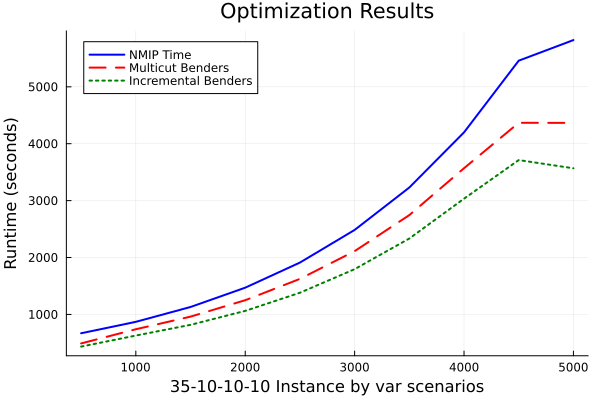

In [4]:
function cases(dfm, O_value, T_value, M_value, E_value)
    Nodes = split.(dfm.Instance, "-") 
    Vertex_Instances = [(Node[1] == string(O_value)) && 
            (Node[2] == string(T_value)) && 
            (Node[3] == string(M_value)) && 
            (Node[4] == string(E_value)) for Node in Nodes]
    
    return dfm[Vertex_Instances, :]
end
dfm = CSV.File("Comparison.csv") |> DataFrame
df = cases(dfm, O, T, M, E)
Instance = df.Scenario
NMIP_time = df.gurobi_runtime
Multicut_Benders = df.Multicut_runtime
Incremental_Benders = df.Incremental_runtime
plot(Instance, [NMIP_time Multicut_Benders Incremental_Benders], 
     label=["NMIP Time" "Multicut Benders" "Incremental Benders"],  # Label for each line
     xlabel="$O-$T-$M-$E Instance by var scenarios",  # Common x-axis title
     ylabel="Runtime (seconds)",  # Common y-axis title
     linewidth=2,
     legend=:topleft,  # Place the legend in the top-right corner
     title="Optimization Results",  # Plot title
     grid=true,  # Enable grid for better readability
     color=[:blue :red :green],  # Color for each series
     linestyle=[:solid :dash :dot])  # Line style for each series

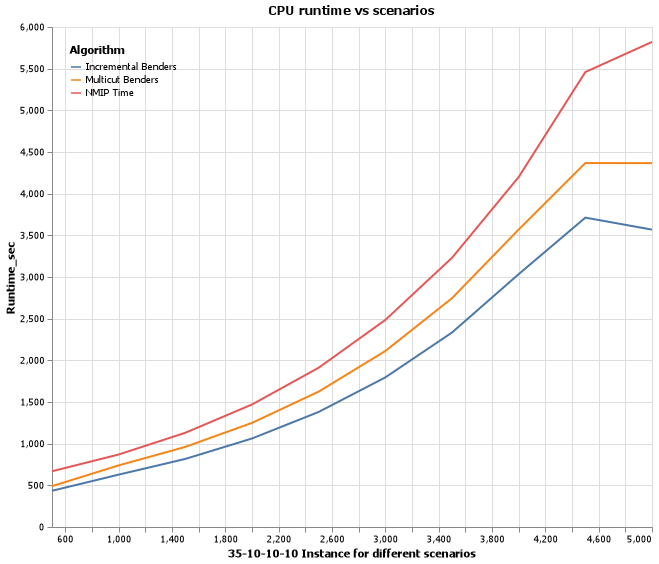

In [6]:
df_long = DataFrame(
    Instance = repeat(Instance,  outer = 3), 
    Runtime_sec = vcat(NMIP_time, Multicut_Benders, Incremental_Benders),  
    Algorithm = repeat(["NMIP Time", "Multicut Benders", "Incremental Benders"], inner=length(Instance)) 
)

# Now plot using VegaLite
@vlplot(
    :line,
    x = {:Instance, title = "$O-$T-$M-$E Instance for different scenarios"},   
    y = :Runtime_sec,                 
    color = {:Algorithm,  legend={orient="top-left"}},              
    data = df_long,                
    width = 600, 
    height = 500,
    linestyle=[:solid :dash :dot],
    title = "CPU runtime vs scenarios",
) 


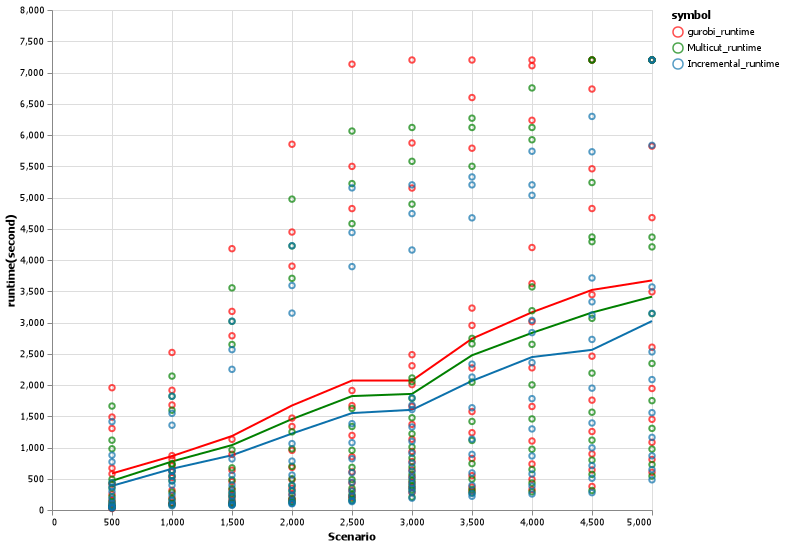

In [5]:
dataset("Trial") |>

@vlplot(:point, x="Scenario", y=:"runtime_sec", width = 600, height = 500, color={:symbol, 
    scale={domain=["gurobi_runtime", "Multicut_runtime", "Incremental_runtime"], range=[ :red, :green, "#0C71AB"]}}
) + 
@vlplot(mark=:line, x="Scenario", y={aggregate="mean","runtime_sec", title = :"runtime(second)"}) + 
@vlplot(:point, x="Scenario", y=:"runtime_sec", color={:symbol,
       scale={ domain=["gurobi_runtime", "Multicut_runtime", "Incremental_runtime"], range=[ :red, :green, "#0C71AB"]}}
)

In [27]:
MAXIMUM_ITERATIONS = 100
ABSOLUTE_OPTIMALITY_GAP = 1e-6
println("Iteration  Lower Bound  Upper Bound          Gap         ret")
optimal_reached = false
π1_history = []
π2_history = []
π6_history = []
LB = []
UB = []
L = []
U =[]
# Keep track of whether a Bender's cut is added for a particular u
optimal_u_values = Set{Int}()
last_optimal_status = Dict{Int, Bool}()
total_inner_iterations = 0  # Initialize the counter for inner iterations

@time begin
 for k in 1:MAXIMUM_ITERATIONS
    optimize!(mm)
    lower_bound = objective_value(mm)
    # println("Lower Bound: $lower_bound")

    x_k = value.(x)
    f2_k = value.(f2)
    f3_k = value.(f3)
    f4_k = value.(f4)
    θ_k  = value.(θ)
    first_stage_k = value.(first_stage)

    for u in 1:10+100*k # Iterate over all u (up to N)
      if u<=N && !(u in optimal_u_values)
        

        # Only process if it's either not optimal, or we haven't checked it before
        ret = solve_subproblem(f3_k, f4_k, u)
        
        if ret.is_feasible
            upper_bound = first_stage_k + ret.obj
            ac_lb = lower_bound - (1/N) * sum(θ_k) + θ_k[u]
            gap = abs(upper_bound - ac_lb) / upper_bound
            push!(UB, upper_bound)
            push!(LB, lower_bound)
            
            # print_iteration(k, ac_lb, upper_bound, gap, ret.obj)

            if gap < ABSOLUTE_OPTIMALITY_GAP
                # println("Optimality achieved for u = $u (gap < threshold)")
                push!(optimal_u_values, u)  # Mark u as optimal
                break

            else
                cut = @constraint(mm, θ[u] >= sum(ret.π1[m, p] * Comp[p] * ef[u, m, p] * 
                    (r1[u, m] * sum(f3[i, m] for i in 1:O) + r2[u, m] * sum(f4[i, m] for i in 1:T)) for m in 1:M for p in 1:Ph) +
                    sum(ret.π2[m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.π2[m] * sum(f4[i, m] for i in 1:T) for m in 1:M)  -
                    D * (1 / E) * sum(b[i] for i in 1:O) * sum(ret.π4[e, p] * Comp[p] for p in 1:Ph for e in 1:E)
                    )
                # println("Added Benders cut for u = $u")
                total_inner_iterations += 1  # Increment inner iteration count when a cut is added

            end
        else
            # If not feasible, generate the cut with u1 and u2
            cut = @constraint(mm, θ[u] >= sum(ret.π1[m, p] * Comp[p] * ef[u, m, p] * 
                    (r1[u, m] * sum(f3[i, m] for i in 1:O) + r2[u, m] * sum(f4[i, m] for i in 1:T)) for m in 1:M for p in 1:Ph) +
                    sum(ret.π2[m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.π2[m] * sum(f4[i, m] for i in 1:T) for m in 1:M)  -
                    D * (1 / E) * sum(b[i] for i in 1:O) * sum(ret.π4[e, p] * Comp[p] for p in 1:Ph for e in 1:E)
            )
            println("Added cut for infeasible u = $u")
            total_inner_iterations += 1  # Increment inner iteration count when a cut is added
        end
      end
    end
    push!(L, sum(LB[i] for i in ((k*N)-N + 1):(k*N))) 
    push!(U, sum(UB[i] for i in ((k*N)-N + 1):(k*N)))
    # After finishing all u iterations for this k, check if optimal was reached for all u
    # If any `u` isn't optimal, we will continue generating cuts
    if all(u in optimal_u_values for u in 1:N) && k < MAXIMUM_ITERATIONS
        println("No further Benders Cut, reached Optimal for all u")
        break  # exit outer loop (k loop) if optimal has been reached for all u
    else
        println("Proceeding to next iteration $(k+1), still checking for optimality for u")
    end
    
 end
end
println("Total inner loop iterations: $total_inner_iterations")

Iteration  Lower Bound  Upper Bound          Gap         ret
Proceeding to next iteration 2, still checking for optimality for u
Proceeding to next iteration 3, still checking for optimality for u
Proceeding to next iteration 4, still checking for optimality for u
Proceeding to next iteration 5, still checking for optimality for u
Proceeding to next iteration 6, still checking for optimality for u
Proceeding to next iteration 7, still checking for optimality for u
Proceeding to next iteration 8, still checking for optimality for u
Proceeding to next iteration 9, still checking for optimality for u
Proceeding to next iteration 10, still checking for optimality for u
Proceeding to next iteration 11, still checking for optimality for u
Proceeding to next iteration 12, still checking for optimality for u
Proceeding to next iteration 13, still checking for optimality for u
Proceeding to next iteration 14, still checking for optimality for u
Proceeding to next iteration 15, still checking fo

  0.037328 seconds (354 allocations: 11.047 KiB)
95631.92386095808


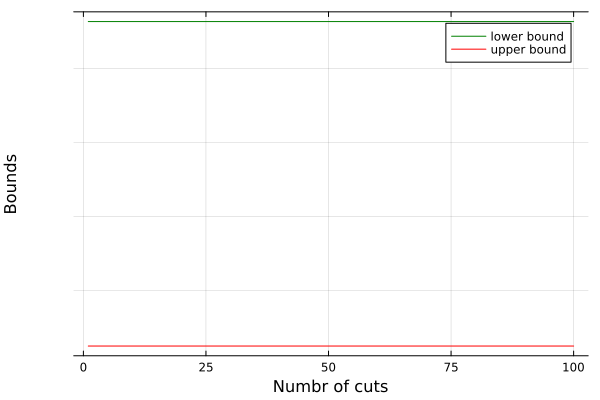

In [28]:
# set_binary.(x)
@time optimize!(mm)
println(objective_value(mm))
plot(L, color = "green", grid = true, framestyle=:box, label = "lower bound", xlabel="Numbr of cuts")
plot!(U, color = "red", grid = true, label = "upper bound", ylabel="Bounds", yaxis=false)
# π1_history

In [43]:
L
open("geek.txt", "w") do file
    for (l, u) in zip(L, U)  # Iterate over both vectors simultaneously
        println(file, "$l\t$u")  # Write each pair of elements in a new line, separated by a tab
    end
end

In [30]:
println("Iteration  Lower Bound  Upper Bound          Gap         ret")
optimal_reached = false
previous_π1 = zeros(M)
previous_π2 = zeros(M)
for k in 1:MAXIMUM_ITERATIONS
    optimize!(mm)
    lower_bound = objective_value(mm)
    println(lower_bound)
    x_k = value.(x)
    f_k = value.(f)
    f2_k = value.(f2)
    f3_k = value.(f3)
    f4_k = value.(f4)
    θ_k  = value.(θ)
    for u in 1:N
         ret = solve_subproblem(f3_k, f4_k, u)
         if ret.is_feasible
             upper_bound = sum(c1[i, j] * f_k[i, j] for i in 1:O for j in 1:O) +
                      sum(c2[i, j] * f2_k[i, j] for i in 1:O for j in 1:T) +
                      sum(c3[i, j] * f3_k[i, j] for i in 1:O for j in 1:M) +
                      sum(c4[i, j] * f4_k[i, j] for i in 1:T for j in 1:M) + 
                      sum(cost_hub[j] * x_k[j, j] for j in 1:O) + ret.obj
             ac_lb = lower_bound - (1/N)*sum(θ_k) + θ_k[u]
             gap = abs(upper_bound - ac_lb) / upper_bound
             print_iteration(k, ac_lb, upper_bound, gap, ret.obj)
             if gap < ABSOLUTE_OPTIMALITY_GAP
                println("No further Benders Cut, reached Optimal")
                optimal_reached = true
                break
             end
        
             cut = @constraint(mm, θ[u] >= sum((ret.π1[m] * r1[u, m] * (1/k) + previous_π1[m] * r1[u, m] * (k-1) * (1/k))* sum(f3[i, m] for i in 1:O) for m in 1:M) +
                sum((ret.π1[m] * r2[u, m] * (1/k) + previous_π1[m] * r2[u, m] * (k-1) * (1/k)) * sum(f4[i, m] for i in 1:T) for m in 1:M) +
                sum((ret.π2[m] * (1/k) + previous_π2[m] * (k-1) * (1/k))* sum(f3[i, m] for i in 1:O) for m in 1:M) +
                sum((ret.π2[m] * (1/k) + previous_π2[m] * (k-1) * (1/k)) * sum(f4[i, m] for i in 1:T) for m in 1:M) - 
                D * (1/E) * sum(b[i] for i in 1:O) * sum(ret.π6[e,p] * Comp[p] for p in 1:Ph for e in 1:E)
                # + (100)* (sum(f3[i, m] - f3_k[i, m] for i in 1:O for m in 1:M))^2 + (100)* (sum(f4[i, m] - f4_k[i, m] for i in 1:T for m in 1:M))^2
            )
             # @info "Adding the cut $(cut)"

        else
            @constraint(mm, 0 >= sum(ret.u1[m] * r1[u, m]  * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.u1[m] * r2[u, m] * sum(f4[i, m] for i in 1:T) for m in 1:M) - 
                    D * (1/E) * sum(b[i] for i in 1:O) * sum(ret.u6[e,p] * Comp[p] for p in 1:Ph for e in 1:E) #+ 
                    # sum(ret.u3[m, e] for m in 1:M for e in 1:E)
                )
        end
        previous_π1 = ret.π1
        previous_π2 = ret.π2
    end
    if optimal_reached
        break  # return optimal solution
    end

end

Iteration  Lower Bound  Upper Bound          Gap         ret
112842.14606571893


LoadError: UndefVarError: `f` not defined

In [12]:
ret1 = solve_subproblem(value.(f3), value.(f4), 1)
ret1.obj

Set parameter Username
Academic license - for non-commercial use only - expires 2025-05-21


71198.18179075714

In [ ]:
# if needed

using JuMP, Dualization
undo = relax_integrality(model)
print(model)
dm = dualize(model; dual_names = DualNames("", ""))
print(dm)

In [33]:
using JuMP
using Gurobi

val = c_Lf* sum(b[i] for i in 1:O) - sum(sum(D * Comp[p] * sum(b[i] for i in 1:O) * (1/E) for p in 1:Ph) for m in 1:M)


9253.5

In [ ]:
cost = rand(O, O, M, E)

In [50]:
# cost2 = rand(3:3, O, O, M)
#c1 = rand(1:1, O, O)
#c2 = rand(1:1, O, T)
#c3 = rand(2:2, O, M)
#c4 = rand(1:1, T, M)
cost_hub = 1000 * ones(O)
cost_MRF = 500 * ones(M)

cost_me = 2 * rand(1:4, M, E)
cost2 = zeros(Float64, O, O, M)  # 3D array with dimensions O x O x M
cost1 = zeros(Float64, O, O, T, M)

# Calculate cost values
for i in 1:O
    for j in 1:O
        for k in 1:M
            cost2[i, j, k] = c1[i, j] + c3[j, k]
        end
    end
end
for i in 1:O
    for j in 1:O
        for t in 1:T
            for m in 1:M
                cost1[i, j, t, m] = c1[i, j] + c2[j, t] + c4[t, m]
            end
        end
    end
end
cost_shtm = cost1
cost_shm = cost2
# Display the cost array
println("Cost array:")
println(cost1)


Cost array:
[9.5 16.5 21.0 17.5 13.5 13.5 14.0 17.5 14.5 16.0; 11.5 14.5 15.0 19.5 13.5 16.5 14.0 21.5 13.5 20.0; 14.5 24.5 13.0 15.5 18.5 13.5 16.0 17.5 13.5 20.0; 14.5 24.5 16.0 11.5 16.5 12.5 13.0 18.5 16.5 16.0; 12.5 22.5 21.0 19.5 9.5 11.5 17.0 22.5 12.5 13.0; 14.5 23.5 15.0 20.5 13.5 8.5 15.0 24.5 18.5 20.0; 14.5 24.5 21.0 19.5 12.5 18.5 9.0 22.5 11.5 14.0; 12.5 18.5 20.0 20.5 16.5 16.5 18.0 15.5 15.5 15.0; 17.5 24.5 21.0 19.5 12.5 13.5 16.0 25.5 8.5 16.0; 16.5 22.5 22.0 20.5 15.5 18.5 11.0 22.5 16.5 10.0;;; 15.0 13.5 23.0 19.5 15.5 14.5 20.0 15.5 19.5 20.0; 17.0 11.5 17.0 21.5 15.5 17.5 20.0 19.5 18.5 24.0; 20.0 21.5 15.0 17.5 20.5 14.5 22.0 15.5 18.5 24.0; 20.0 21.5 18.0 13.5 18.5 13.5 19.0 16.5 21.5 20.0; 18.0 19.5 23.0 21.5 11.5 12.5 23.0 20.5 17.5 17.0; 20.0 20.5 17.0 22.5 15.5 9.5 21.0 22.5 23.5 24.0; 20.0 21.5 23.0 21.5 14.5 19.5 15.0 20.5 16.5 18.0; 18.0 15.5 22.0 22.5 18.5 17.5 24.0 13.5 20.5 19.0; 23.0 21.5 23.0 21.5 14.5 14.5 22.0 23.5 13.5 20.0; 22.0 19.5 24.0 22.5 17

In [17]:
cost1[:,:,1]

4×4 Matrix{Float64}:
 3.0  3.0  3.0  3.0
 3.0  3.0  3.0  3.0
 3.0  3.0  3.0  3.0
 3.0  3.0  3.0  3.0

In [86]:
model = JuMP.direct_model(Gurobi.Optimizer())
set_time_limit_sec(model, 100.0)
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Here and Now)
@variable(model, 0 <= x1[1:O, 1:O, 1:T, 1:M] <=1, Bin)
@variable(model, 0 <= x2[1:O, 1:O, 1:M] <=1, Bin)
# @variable(model, 0 <= v[1:O, 1:O] <=1, Bin)
@variable(model, 0 <= y[1:O] <=1, Bin)
# @variable(model, 0 <= z[1:M] <=1, Bin)
@constraint(model, assgn[i in 1:O], sum(x1[i, j, t, m] for j in 1:O for t in 1:T for m in 1:M) + sum(x2[i, j, m] for j in 1:O for m in 1:M) == 1)
@constraint(model, hub_cap[j in 1:O], sum(b[i] * x1[i, j, t, m] for i in 1:O for t in 1:T for m in 1:M) 
    + sum(b[i] * x2[i, j, m] for i in 1:O for m in 1:M) <= cap_h[j]*y[j])

# @constraint(model, MRF_cap[m in 1:M], sum(b[i] * x1[i, j, t, m] for i in 1:O for j in 1:O for t in 1:T) 
  #  + sum(b[i] * x2[i, j, m] for i in 1:O for j in 1:O) <= cap_z1[m]*z[m])
Hub_cap_cost = sum(cost_hub[j] * y[j] for j in 1:O) 

first_stage_cost = sum(cost_shtm[i, j, t, m] * x1[i, j, t, m] * b[i] for i in 1:O for j in 1:O for t in 1:T for m in 1:M) + 
        sum(cost_shm[i, j, m] * x2[i, j, m] * b[i] for i in 1:O for j in 1:O for m in 1:M) + Hub_cap_cost
        # + MRF_cap_cost
#second stage
@variable(model, 0 <= w1[1:N, 1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= s1[1:N, 1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)

@constraint(model, d1[n in 1:N, m in 1:M], w1[n, m, 1] == sum(x1[i, j, t, m] *b[i] for i in 1:O for j in 1:O for t in 1:T)*r1[n, m]  + 
    sum(x2[i, j, m] *b[i] for i in 1:O for j in 1:O)*r2[n, m])
# @constraint(model, d2[n in 1:N, m in 1:M], -w1[n, m, 1] >= -sum(f3[j,m] for j in 1:O)*r1[n, m] - sum(f4[j,m] for j in 1:T)*r2[n, m])
@constraint(model, d2[n in 1:N, m in 1:M, p in 1:Ph], w1[n, m, p+1] == w1[n,m,p] -sum(s1[n, m, e, p] for e in 1:E))
# @constraint(model, d3[n in 1:N, m in 1:M, j in 1:E, p in 1:Ph], s1[n, m, j, p] <= big_M * y1[n, m, j])
# @constraint(model, d5[n in 1:N, m in 1:M, p in 1:Ph], sum(y1[n, m, j, p] for j in 1:E) <= 1)
@constraint(model, d4[n in 1:N, m in 1:M, e in 1:E, p in 1:Ph], s1[n, m, e, p]  <= w1[n, m, 1]*Comp[p]*ef[p])
# @constraint(model, d5[n in 1:N, e in 1:E-1, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M)- sum(s1[n, m, e+1, p] for m in 1:M)  <=0)
@constraint(model, d5[n in 1:N, e in 1:E, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M) >= D * Comp[p] * sum(b[i] for i in 1:O) * (1/E))

MRF_cost = c_Lf * (N*sum(b[i] for i in 1:O) - sum(s1[n, m, e, p] for n in 1:N for m in 1:M for e in 1:E for p in 1:Ph))
@objective(model, Min, first_stage_cost + (1/N) * MRF_cost)
optimize!(model)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-05-21
Set parameter TimeLimit to value 100
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1255U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 710 rows, 1300 columns and 7380 nonzeros
Model fingerprint: 0x78e3881a
Variable types: 490 continuous, 810 integer (810 binary)
Coefficient statistics:
  Matrix range     [1e-02, 2e+02]
  Objective range  [1e+01, 2e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [5e-01, 8e+00]
Found heuristic solution: objective 22198.600000
Presolve removed 552 rows and 792 columns
Presolve time: 0.03s
Presolved: 158 rows, 508 columns, 2538 nonzeros
Found heuristic solution: objective 16698.600000
Variable types: 80 continuous, 428 integer (410 binary)

Root relaxation: objective 9.022180e+03, 138 iteratio

In [87]:
value.(first_stage_cost)

6435.0

In [7]:
model = Model(Gurobi.Optimizer)
set_silent(model)
Big_V = 0
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Here and Now)

@variable(model, θ[1:N] >= Big_V)
@variable(model, 0 <= x1[1:O, 1:O, 1:T, 1:M] <=1, Bin)
@variable(model, 0 <= x2[1:O, 1:O, 1:M] <=1, Bin)
# @variable(model, 0 <= v[1:O, 1:O] <=1, Bin)
@variable(model, 0 <= y[1:O] <=1, Bin)
# @variable(model, 0 <= z[1:M] <=1, Bin)
@constraint(model, assgn[i in 1:O], sum(x1[i, j, t, m] for j in 1:O for t in 1:T for m in 1:M) + sum(x2[i, j, m] for j in 1:O for m in 1:M) == 1)
@constraint(model, hub_cap[j in 1:O], sum(b[i] * x1[i, j, t, m] for i in 1:O for t in 1:T for m in 1:M) 
    + sum(b[i] * x2[i, j, m] for i in 1:O for m in 1:M) <= cap_h[j]*y[j])

# @constraint(model, MRF_cap[m in 1:M], sum(b[i] * x1[i, j, t, m] for i in 1:O for j in 1:O for t in 1:T) 
  #  + sum(b[i] * x2[i, j, m] for i in 1:O for j in 1:O) <= cap_z1[m]*z[m])
Hub_cap_cost = sum(cost_hub[j] * y[j] for j in 1:O) 

first_stage_cost = sum(cost_shtm[i, j, t, m] * x1[i, j, t, m] * b[i] for i in 1:O for j in 1:O for t in 1:T for m in 1:M) + 
        sum(cost_shm[i, j, m] * x2[i, j, m] * b[i] for i in 1:O for j in 1:O for m in 1:M) + Hub_cap_cost
@objective(model, Min, first_stage_cost+(1/N) * sum(θ[n] for n in 1:N))
optimize!(model)
objective_value(model)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-05-21


LoadError: UndefVarError: `cost_shtm` not defined

In [8]:
function solve_subproblem(x1, x2, u)
    sm = Model(Gurobi.Optimizer)
    set_silent(sm)
    @variable(sm, 0 <= w1[1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
    @variable(sm, 0 <= s1[1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)
    # @variable(sm, 0 <= y1[1:M, 1:E]) # Integer_Recourse variable
    con = @constraint(sm, d1[m in 1:M], w1[m, 1] == sum(x1[i, j, t, m] *b[i] for i in 1:O for j in 1:O for t in 1:T) *r1[u, m]  + 
        sum(x2[i, j, m] *b[i] for i in 1:O for j in 1:O) *r2[u, m] )
    # @constraint(model, dn[n in 1:N, m in 1:M, p in 1:Ph], w1[n, m, Ph+1] == w1[n, m, p] - s1[n, m, p])
    con2 = @constraint(sm, d2[ m in 1:M, p in 1:Ph], w1[m, p+1] == w1[m,p] -sum(s1[m, e, p] for e in 1:E))
    # con3 = @constraint(sm, d3[m in 1:M, j in 1:E, p in 1:Ph], s1[m, j, p] <= big_M * y1[m, j])
    # con4 = @constraint(sm, d4[m in 1:M, j in 1:E], sum(s1[m, j, p] for p in 1:Ph) <= big_M * y1[m, j])
    con5 = @constraint(sm, d5[m in 1:M, e in 1:E, p in 1:Ph], s1[m, e, p]  <= w1[m, 1]*Comp[p]*ef[p])
    # conb = @constraint(sm, db[m in 1:M, j in 1:E], y1[m, j] <= 1)
    con6 = @constraint(sm, d6[e in 1:E, p in 1:Ph], -sum(s1[m, e, p] for m in 1:M) <= -D * Comp[p] * sum(b[i] for i in 1:O) * (1/E))
    MRF_cost = c_Lf * (sum(b[i] for i in 1:O) - sum(s1[m, e, p] for m in 1:M for e in 1:E for p in 1:Ph)) 
        + sum(cost_me[m, e] * (s1[m, e, p]) for m in 1:M for e in 1:E for p in 1:Ph)
    @objective(sm, Min, MRF_cost)
    optimize!(sm)
    if is_solved_and_feasible(sm; dual = true)
        return (is_feasible = true, obj = objective_value(sm), 
            w1 = value.(w1), s1 = value.(s1), π1 = dual.(con), π6 = dual.(con6)) # π3 = dual.(conb), π4 = dual.(con4)
    end
    return (is_feasible = false, v = dual_objective_value(sm),
          u1 = dual.(con), u3 = dual.(conb), u6 = dual.(con6)) # u4 = dual.(con4)
end
function print_iteration(k, args...)
            f(x) = Printf.@sprintf("%12.4e", x)
            println(lpad(k, 9), " ", join(f.(args), " "))
            return
end

print_iteration (generic function with 1 method)

In [99]:
solve_subproblem(value.(x1), value.(x2), 5)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-05-21


(is_feasible = true, obj = 5628.6000000000095, w1 = [128.73999999999998 52.691235999999975 … 8.110619999999999 0.0; 174.45 125.71576499999998 … 37.73505 0.0], s1 = [30.163781999999998 30.163781999999998 … 7.860600000000002 7.860600000000002; 40.873635 0.0 … 0.0 0.0;;; 5.955 0.0 … 5.955 5.955; 0.0 31.233614999999972 … 0.0 0.0;;; 7.897815999999974 0.0 … 0.0 0.0; 0.0 11.1648 … 2.382 2.382;;; 2.382 2.382 … 2.382 0.0; 0.0 0.0 … 0.0 2.382;;; 0.0 0.0 … 0.0 1.191; 6.454649999999999 6.454649999999999 … 1.191 0.0;;; 0.0 1.191 … 1.191 0.0; 6.105749999999999 0.0 … 0.0 1.191;;; 0.47640000000000005 0.47640000000000005 … 0.0 0.0; 0.0 0.0 … 0.47640000000000005 0.47640000000000005;;; 0.0 0.0 … 0.0 8.110619999999999; 10.99035 2.382 … 10.99035 10.99035], π1 = [-60.0, -60.0], π6 = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

In [10]:
ABSOLUTE_OPTIMALITY_GAP = 1e-6
sp_solves = 0
gap = []
# Initialize variables
Flag_Status = true
π1_history = []
π2_history = []
π6_history = []

function my_callback(cb_data)
    status = callback_node_status(cb_data, mm)

    # Only add constraints if the node is an integer solution
    if status != MOI.CALLBACK_NODE_STATUS_INTEGER
        return
    end

    # Read values from the callback data
    x_k = callback_value.(cb_data, x)
    f2_k = callback_value.(cb_data, f2)
    f3_k = callback_value.(cb_data, f3)
    f4_k = callback_value.(cb_data, f4)
    θ_k = callback_value.(cb_data, θ)
    first_stage_k = callback_value.(cb_data, first_stage)
    lower_bound = first_stage_k + (1 / N) * sum(θ_k)

    global k
    revisited_u = Set()  # Set to track which u have been revisited (to avoid re-checking them)
    add_constraint_needed = false  # Flag to track if a constraint is needed

    # Phase 1: Check the gap condition for all u <= N
    for u in 1:min(k, N)  # Ensure we only check up to N
        
            ret = solve_subproblem(f3_k, f4_k, u)
            upper_bound = first_stage_k + ret.obj
            ac_lb = lower_bound - (1 / N) * sum(θ_k) + θ_k[u]
            gap = abs(upper_bound - ac_lb) / upper_bound

            # If the gap is larger than the threshold, add a constraint and revisit this u
            if gap >= ABSOLUTE_OPTIMALITY_GAP
                global sp_solves += 1
                cut = @build_constraint(
                    θ[u] >= sum(ret.π1[m] * r1[u, m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.π1[m] * r2[u, m] * sum(f4[i, m] for i in 1:T) for m in 1:M) +
                    sum(ret.π2[m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.π2[m] * sum(f4[i, m] for i in 1:T) for m in 1:M)  -
                    D * (1 / E) * sum(b[i] for i in 1:O) * sum(ret.π6[e, p] * Comp[p] for p in 1:Ph for e in 1:E)
                )
                # @info("add a cut for $u")
                MOI.submit(mm, MOI.LazyConstraint(cb_data), cut)
            else
                # @info("$u reach gap")
            end
    end

    # If we have added any constraints, the callback will continue and check again

    if k <= N-1
        @info("add next sample subset")
        cut2 = @build_constraint(
        sum(θ[n] * (1/(N-k)) for n in (k+1):N) >= sum((1/k) * θ_k[w] for w in 1:k))
        MOI.submit(mm, MOI.LazyConstraint(cb_data), cut2)
    end
    k += R
    return
end
set_attribute(mm, MOI.LazyConstraintCallback(), my_callback)

In [ ]:
println("Iteration  Lower Bound  Upper Bound          Gap")
MAXIMUM_ITERATIONS = 60
ABSOLUTE_OPTIMALITY_GAP = 1e-6
optimal_reached = false
for k in 1:MAXIMUM_ITERATIONS
    optimize!(model)
    lower_bound = objective_value(model)
    println(lower_bound)
    x1_k = value.(x1)
    x2_k = value.(x2)
    y_k = value.(y)
    for u in 1:N
         ret = solve_subproblem(x1_k, x2_k, u)
         if ret.is_feasible
             upper_bound = sum(cost_shtm[i, j, t, m] * x1_k[i, j, t, m] * b[i] for i in 1:O for j in 1:O if i!=j for t in 1:T for m in 1:M) + 
                       sum(cost_shm[i, j, m] * x2_k[i, j, m] * b[i] for i in 1:O for j in 1:O if i!= j for m in 1:M) + 
             sum(cost_hub[j] * y_k[j] for j in 1:O) +  ret.obj
             gap = abs(upper_bound - lower_bound) / abs(upper_bound)
             print_iteration(k, lower_bound, upper_bound, gap)
             if gap < ABSOLUTE_OPTIMALITY_GAP
                println("No further Benders Cut, reached Optimal")
                optimal_reached = true
                break
             end
        
             cut = @constraint(model, θ[u] >= ret.obj # + 
                    # sum(ret.π3[m, e] for m in 1:M for e in 1:E)
                )
             # @info "Adding the cut $(cut)"

        else
            @constraint(model, 0 >= sum(ret.u1[m] * r1[u, m] * sum(x1[i, j, t, m] * b[i] for i in 1:O for j in 1:O for t in 1:T) for m in 1:M) +
                    sum(ret.u1[m] * r2[u, m] * sum(x2[i, j, m] * b[i] for i in 1:O for j in 1:O) for m in 1:M) - 
                    D * (1/E) * sum(b[i] for i in 1:O) * sum(ret.u6[e,p] * Comp[p] for p in 1:Ph for e in 1:E) #+ 
                    # sum(ret.u3[m, e] for m in 1:M for e in 1:E)
                )
        end
    end
    if optimal_reached
        break  # return optimal solution
    end

end

In [17]:
optimize!(model)
# print(value.(θ))
objective_value(model)

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1255U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 40297 rows, 164810 columns and 755775 nonzeros
Coefficient statistics:
  Matrix range     [1e-02, 4e+02]
  Objective range  [6e-01, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+01]

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Optimal objective  3.077850964e+05

User-callback calls 15, time in user-callback 0.00 sec


307785.09636414057

In [ ]:
using BranchAndBound
using JuMP
using HiGHS

const BB = BranchAndBound



model = Model(HiGHS.Optimizer)
@variable(model, 0 <= w1[1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= s1[1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)
@variable(model, 0 <= y1[1:M, 1:E] <= 1) # Integer_Recourse variable
con = @constraint(model, d1[m in 1:M], w1[m, 1] == sum(value.(x1[i, j, t, m]) *b[i] for i in 1:O for j in 1:O for t in 1:T) *r1[5, m]  + 
sum(value.(x2[i, j, m]) *b[i] for i in 1:O for j in 1:O) *r2[5, m] )
con2 = @constraint(model, d2[ m in 1:M, p in 1:Ph], w1[m, p+1] == w1[m,p] -sum(s1[m, e, p] for e in 1:E))
con3 = @constraint(model, d3[m in 1:M, j in 1:E, p in 1:Ph], s1[m, j, p] <= big_M * y1[m, j])
con4 = @constraint(model, d4[m in 1:M, j in 1:E], sum(s1[m, j, p] for p in 1:Ph) <= big_M * y1[m, j])
con5 = @constraint(model, d5[m in 1:M, e in 1:E, p in 1:Ph], s1[m, e, p]  <= w1[m, 1]*Comp[p]*ef[p])

con6 = @constraint(model, d6[e in 1:E, p in 1:Ph], -sum(s1[m, e, p] for m in 1:M) <= -D * Comp[p] * sum(b[i] for i in 1:O) * 0.01)
MRF_cost = (sum(c_Lf[m] * w1[m, Ph+1] for m in 1:M) + sum(cost_me[m, e] * (s1[m, e, p] + y1[m, e]) for m in 1:M  for e in 1:E for p in 1:Ph))
@objective(model, Min, MRF_cost)


# Initialize BNB tree
tree = BB.initialize_tree(model)

# User-defined branch function
function BB.branch!(tree::BB.AbstractTree, node::BB.AbstractNode)
    @info " Node id $(node.id), status $(node.solution_status), bound $(node.bound)"
    
    if node.bound >= tree.best_incumbent
        @info " Fathomed by bound"
        return
    end
    
    if node.solution_status in [MOI.OPTIMAL, MOI.LOCALLY_SOLVED]
        for i in 1:M
            for j in 1:E
                if !isinteger(value(node.solution[y1[i, j]]))  # Access value directly
                    @info " Branch at y1[$i, $j] = $(value(node.solution[y1[i, j]])), y1[$i, $j] >= $(ceil(value(node.solution[y1[i, j]]))), y1[$i, $j] <= $(floor(value(node.solution[y1[i, j]])))"
                    child1 = BB.create_child_node_with_lb(node, y1[i,j], ceil(value(node.solution[y1[i, j]])))
                    child2 = BB.create_child_node_with_ub(node, y1[i, j], floor(value(node.solution[y1[i, j]])))
                    BB.push!(tree, child1)
                    BB.push!(tree, child2)
                    return
                end
            end
        end
        
        if node.bound < tree.best_incumbent
            @info " New incumbent bound: $(node.bound) with solution $(value.(y1))"
            tree.best_incumbent = node.bound
        end
    else
        @info " Fathomed by solution status: $(node.solution_status)"
    end
end

function BB.termination(tree::BB.AbstractTree)
    @info "Tree nodes: processed $(length(tree.processed)), left $(length(tree.nodes)), total $(tree.node_counter), best bound $(tree.best_bound), best incumbent $(tree.best_incumbent)"
    if BB.isempty(tree)
        @info "Completed the tree search with solution"
        return true
    end
    if length(tree.processed) >= 2000
        @info "Reached node limit"
        return true
    end
    return false
end

BB.run(tree)

In [12]:
for m in 1:M
    for e in 1:E
        println("y1[$m, $e] = ", value(y1[m, e]))
    end
end

y1[1, 1] = 0.0
y1[1, 2] = 0.0
y1[2, 1] = 1.0
y1[2, 2] = 0.0
y1[3, 1] = 1.0
y1[3, 2] = 0.0016778437054678005


In [98]:
optimize!(model)
if termination_status(model) != MOI.OPTIMAL
    println("Model is not feasible.")
    return
end

Solving LP without presolve or with basis
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     1.3954196959e+03 Pr: 2(1.61979) 0s
          1     1.3954177484e+03 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 1
Objective value     :  1.3954177484e+03
HiGHS run time      :          0.00


In [62]:
using Dualization
DM = 10000
MRF_cost = 0
model = Model(HiGHS.Optimizer)
@variable(model, 0 <= w1[1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= s1[1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)
@variable(model, 0 <= y1[1:M, 1:E]) # Integer_Recourse variable
@variable(model, 0 <= A1[1:M]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= A2[1:M, 1:Ph]) # continuous_Recourse variable(sorted recovery)
@variable(model, 0 <= sc3[1:M, 1:E, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= sc4[1:M, 1:E]) # continuous_Recourse variable(sorted recovery)
@variable(model, 0 <= sc5[1:M, 1:E, 1:Ph]) # Integer_Recourse variable
@variable(model, 0 <= su6[1:E, 1:Ph]) # Integer_Recourse variable
@variable(model, 0 <= A6[1:E, 1:Ph]) # Integer_Recourse variable
@variable(model, 0 <= scb[1:M, 1:E]) # Integer_Recourse variable
con = @constraint(model, d1[m in 1:M], w1[m, 1] + A1[m] == sum(value.(x1[i, j, t, m]) *b[i] for i in 1:O for j in 1:O for t in 1:T) *r1[1, m]  + 
        sum(value.(x2[i, j, m]) *b[i] for i in 1:O for j in 1:O) *r2[1, m])
    # @constraint(model, dn[n in 1:N, m in 1:M, p in 1:Ph], w1[n, m, Ph+1] == w1[n, m, p] - s1[n, m, p])
con2 = @constraint(model, d2[ m in 1:M, p in 1:Ph], w1[m, p+1] + A2[m, p] - w1[m,p] + sum(s1[m, e, p] for e in 1:E) == 0)
con3 = @constraint(model, d3[m in 1:M, j in 1:E, p in 1:Ph], s1[m, j, p] + sc3[m, j, p] - big_M * y1[m, j] == 0)
con4 = @constraint(model, d4[m in 1:M, j in 1:E], sum(s1[m, j, p] for p in 1:Ph) + sc4[m, j] - big_M * y1[m, j] == 0)
con5 = @constraint(model, d5[m in 1:M, j in 1:E, p in 1:Ph], s1[m, j, p] + sc5[m, j, p] - w1[m, 1]*Comp[p]*ef[p] == 0)
con6 = @constraint(model, d6[j in 1:E, p in 1:Ph], sum(s1[m, j, p] for m in 1:M) - su6[j, p] + A6[j, p]
    == D * Comp[p] * sum(b[i] for i in 1:O) * 0.01)
conb = @constraint(model, db[m in 1:M, j in 1:E], y1[m, j] + scb[m, j] == 1)
# gccon1 = @constraint(model, gc1,  0.00002178 * A1[1] + 0.9999 * sc3[1,1,1] + 0.0001 * su6[1,1] >=0.00164002)
MRF_cost = (sum(c_Lf[m] * w1[m, Ph+1] for m in 1:M) + sum(cost_me[m, e] * (s1[m, e, p] + y1[m, e]) for m in 1:M  for e in 1:E for p in 1:Ph)) +
  DM * (sum(A1[m] + A2[m, p] + A6[j, p] for m in 1:M for j in 1:E for p in 1:Ph))
new_row = MRF_cost - DM * sum(w1[m, 1] + A1[m] - sum(value.(x1[i, j, t, m]) *b[i] for i in 1:O for j in 1:O for t in 1:T) *r1[1, m]  + 
        sum(value.(x2[i, j, m]) *b[i] for i in 1:O for j in 1:O) *r2[1, m] for m in 1:M) - 
        DM * sum(w1[m, p+1] + A2[m, p] - w1[m,p] + sum(s1[m, e, p] for e in 1:E) for m in 1:M for p in 1:Ph) -  
        DM * sum(sum(s1[m, j, p] for m in 1:M) - su6[j, p] + A6[j, p] - D * Comp[p] * sum(b[i] for i in 1:O) * 0.01  for j in 1:E for p in 1:Ph)  
@objective(model, Max, -new_row)
optimize!(model)
# slack_cost = 0 * sum(sc3[m, j, p] + sc4[m, j] + sc5[m, j, p] + sc6[j, p] for m in 1:M for j in 1:E for p in 1:Ph)
value.(y1)
# new_row


Presolving model
64 rows, 108 cols, 230 nonzeros
42 rows, 84 cols, 164 nonzeros
42 rows, 82 cols, 162 nonzeros
Presolve : Reductions: rows 42(-232); columns 82(-386); elements 162(-802)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -3.8919432079e+04 Ph1: 2(1); Du: 2(38919.4) 0s
         44     5.8291656000e+02 Pr: 0(0) 0s
         44     5.8291656000e+02 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 44
Objective value     : -5.8291656000e+02
HiGHS run time      :          0.00


8×5 Matrix{Float64}:
 -0.0         -0.0       -0.0         -0.0         -0.0
 -0.0         -0.0       -0.0         -0.0         -0.0
 -0.0         -0.0       -0.0         -0.0         -0.0
  0.0051508    0.0        0.0023384    0.0          0.0051508
 -0.0         -0.0       -0.0         -0.0         -0.0
 -0.0         -0.0       -0.0         -0.0         -0.0
  0.00672375   7.134e-5   0.00298116   0.00672375   0.0
 -0.0         -0.0       -0.0         -0.0         -0.0

In [64]:
using NLPModelsJuMP

nlp = MathOptNLPModel(model) # the input "< model >" is the name of the model you created by JuMP before with variables and constraints (and optionally the objective function) attached to it.

x = zeros(nlp.meta.nvar)
c = NLPModelsJuMP.grad(nlp, x)
A = Matrix(NLPModelsJuMP.jac(nlp, x))
b = nlp.meta.ucon
# b = [62.12418376480, 0, 0, 0, 0, 0.14751, 1.0]

274-element Vector{Float64}:
   0.0
   0.0
   0.0
 126.4
   0.0
   0.0
 165.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   ⋮
   1.0
   1.0
   1.0
   1.0
   1.0
   1.0
   1.0
   1.0
   1.0
   1.0
   1.0
   1.0

In [16]:
c

13-element Vector{Float64}:
     -0.0
   9700.0
  19996.0
     -4.0
     -0.0
     -0.0
      0.0
      0.0
      0.0
      0.0
 -10000.0
     -0.0
      0.0

In [10]:
function to_tableau(c, A, b)
    m, n = size(A)
    tableau = zeros(Float64, m + 1, n + m + 1)  # Tableau with extra columns for slack variables and RHS

    # Fill the tableau
    tableau[1:m, 1:n] = A
    tableau[1:m, end] = b
    tableau[end, 1:n] = c

    return tableau
end

function can_be_improved(tableau)
    z = tableau[end, 1:end-1]  # Objective row without the RHS
    return any(x -> x > 0, z)  # Check for any positive entries
end

function get_pivot_position(tableau)
    z = tableau[end, 1:end-1]  # Objective row without the RHS
    column = findfirst(x -> x > 0, z)  # Find the first positive entry in the objective row

    if column === nothing
        error("No positive entry found in the objective row; the solution might be optimal.")
    end

    # Calculate restrictions (ratio test)
    restrictions = []
    for i in 1:(size(tableau, 1) - 1)
        el = tableau[i, column]
        if el > 0
            push!(restrictions, tableau[i, end] / el)  # Ratio of RHS / pivot element
        else
            push!(restrictions, Inf)  # Infeasible row
        end
    end

    if all(isinf.(restrictions))
        error("Unbounded solution; no valid pivot row found.")
    end

    row = argmin(restrictions)  # Select the row with the minimum ratio
    return row, column
end

function pivot_step(tableau, pivot_position)
    i, j = pivot_position
    pivot_value = tableau[i, j]

    new_tableau = copy(tableau)  # Copy the tableau to avoid modifying in place
    new_tableau[i, :] = tableau[i, :] / pivot_value  # Normalize the pivot row

    # Perform row operations to zero out the pivot column in other rows
    for k in 1:size(tableau, 1)
        if k != i
            multiplier = tableau[k, j]
            new_tableau[k, :] -= multiplier * new_tableau[i, :]
        end
    end

    return new_tableau
end

function is_basic(column)
    return sum(column .== 1) == 1 && sum(column .== 0) == length(column) - 1
end

function get_solution(tableau)
    m, n = size(tableau)
    solution = zeros(n-1)  # Initialize the solution vector

    for j in 1:(n-1)
        col = tableau[1:m-1, j]
        if is_basic(col)
            row = findfirst(x -> x == 1, col)
            solution[j] = tableau[row, end]  # Get the solution for basic variables
        end
    end

    return solution
end

function simplex(c, A, b)
    tableau = to_tableau(c, A, b)

    while can_be_improved(tableau)
        pivot_position = get_pivot_position(tableau)
        tableau = pivot_step(tableau, pivot_position)
    end

    return get_solution(tableau), tableau
end


# Run the simplex algorithm
solution, final_tableau = simplex(c, A, b)

# Print the solution and final tableau
println("Optimal solution: ", solution)
println("Final Simplex tableau:")
for row in eachrow(final_tableau)
    println(row)
end


LoadError: UndefVarError: `A` not defined

In [ ]:
m = Model(HiGHS.Optimizer)
@variable(m, x[1:2] >= 0)
@objective(m, Min, c_2' * x)

con = @constraint(m, A_2 * x .<= b)


tree = BB.initialize_tree(m)

    # User-defined branch function inside subproblem
function BB_branch!(tree::BB.AbstractTree, node::BB.AbstractNode)
        @info "Node id $(node.id), status $(node.solution_status), bound $(node.bound)"

        # Check if the node is fathomed by the bound
        if node.bound >= tree.best_incumbent
            @info "Fathomed by bound"

        # Check if the solution is optimal or locally solved
        elseif node.solution_status in [MOI.OPTIMAL, MOI.LOCALLY_SOLVED]
            # Use the passed x directly
            for i in 1:2  # Assuming y has 2 dimensions
                x_value = node.solution[x[i]]  # This should work since y is defined in the subproblem model
                if !isinteger(x_value)
                    @info "Branch at y[$i] = $(y_value), y >= $(ceil(y_value)), y <= $(floor(y_value))"
                    child1 = BB.create_child_node_with_lb(node, y[i], ceil(y_value))
                    child2 = BB.create_child_node_with_ub(node, y[i], floor(y_value))
                    BB.push!(tree, child1)
                    BB.push!(tree, child2)
                    return  # Exit after branching
                end
            end

            # Update the best incumbent bound if applicable
            if node.bound < tree.best_incumbent
                @info "New incumbent bound: $(node.bound)"
                tree.best_incumbent = node.bound
            end
        else
            @info "Fathomed by solution status: $(node.solution_status)"
        end
end

BB.run(tree)

In [ ]:
model = Model(HiGHS.Optimizer)
@variable(model, x[1:dim_x] >= 0, Int)
@variable(model, y[1:dim_y] >= 0)
@objective(model, Min, c_1' * x + c_2' * y)
@constraint(model, A_2 * y .<= b - A_1 * x)
optimize!(model)

In [ ]:
value.(x)

In [ ]:
@testset "MIP problem absolute and relative gaps" begin
        m = Model(HiGHS.Optimizer)
        set_optimizer_attribute(m, "log_to_console", false)
        @variable(m, y[1:dim_y] >= 0)
        con = @constraint(m, A_2 * y .<= b - A_1 * value.(x))
        @objective(m, Min, c_2' * y)
        abs_gap_limit = 1e-2
        bnb_model = BB.initialize(;
            branch_strategy = BB.MOST_INFEASIBLE(),
            Node = MIPNode,
            root = m,
            sense = objective_sense(m) == MOI.MAX_SENSE ? :Max : :Min,
            dual_gap_limit = 1e-5,
            abs_gap_limit = abs_gap_limit,
        )
        BB.set_root!(bnb_model, (
            lbs = zeros(length(y)),
            ubs = fill(Inf, length(y)),
            status = MOI.OPTIMIZE_NOT_CALLED
        ))

        BB.optimize!(bnb_model)

        sol_x = BB.get_solution(bnb_model)
        @assert is_solved_and_feasible(m; dual = true)
        return (obj = objective_value(m), y = value.(y), π = dual.(con))
end

In [ ]:
using BranchAndBound
using JuMP
using HiGHS

const BB = BranchAndBound

# continuous relaxation of MILP
m = Model(HiGHS.Optimizer)

# The following will be supported in the later version of JuMP.
# @variable(m, x >= 0, Int)
# @variable(m, y >= 0, Int)
# undo_relax = JuMP.relax_integrality(m)


@variable(m, y[1:2] >= 1.5)
@objective(m, Min, c_2' * y)
@constraint(m, A_2 * y .<= b - A_1 * value.(x))

# Initialize BNB tree
tree = BB.initialize_tree(m)

# User-defined branch function
function BB.branch!(tree::BB.AbstractTree, node::BB.AbstractNode)
    @info " Node id $(node.id), status $(node.solution_status), bound $(node.bound)"
    
    # Check if the node is fathomed by the bound
    if node.bound >= tree.best_incumbent
        @info " Fathomed by bound"
        return
    end
    
    # Check if the solution is optimal or locally solved
    if node.solution_status in [MOI.OPTIMAL, MOI.LOCALLY_SOLVED]
        # Check each variable x for branching
 
        
        # Check each variable y for branching
        for i in 1:2  # Assuming y has 2 dimensions
            if !isinteger(node.solution[y[i]])
                @info " Branch at y[$i] = $(node.solution[y[i]]), y >= $(ceil(node.solution[y[i]])), y <= $(floor(node.solution[y[i]]))"
                child1 = BB.create_child_node_with_lb(node, y[i], ceil(node.solution[y[i]]))
                child2 = BB.create_child_node_with_ub(node, y[i], floor(node.solution[y[i]]))
                BB.push!(tree, child1)
                BB.push!(tree, child2)
                return  # Exit after branching
            end
        end
        
        # Update the best incumbent bound if applicable
        if node.bound < tree.best_incumbent
            @info " New incumbent bound: $(node.bound)"
            tree.best_incumbent = node.bound
        end
    else
        @info " Fathomed by solution status: $(node.solution_status)"
    end
end

function BB.termination(tree::BB.AbstractTree)
    @info "Tree nodes: processed $(length(tree.processed)), left $(length(tree.nodes)), total $(tree.node_counter), best bound $(tree.best_bound), best incumbent $(tree.best_incumbent)"
    if BB.isempty(tree)
        @info "Completed the tree search"
        return true
    end
    if length(tree.processed) >= 20
        @info "Reached node limit"
        return true
    end
    return false
end

BB.run(tree)

In [2]:
import Pkg

In [4]:
Pkg.add("JuMP")

   Resolving package versions...
   Installed SolverCore ──── v0.3.8
   Installed NLPModelsJuMP ─ v0.13.2
    Updating `C:\Users\wahad\.julia\environments\v1.9\Project.toml`
  [792afdf1] + NLPModelsJuMP v0.13.2
    Updating `C:\Users\wahad\.julia\environments\v1.9\Manifest.toml`
  [792afdf1] + NLPModelsJuMP v0.13.2
  [ff4d7338] + SolverCore v0.3.8
Precompiling project...
  ✓ SolverCore
  ✓ NLPModelsJuMP
  2 dependencies successfully precompiled in 17 seconds. 282 already precompiled.


In [22]:
M = -sum(G)
model = Model(HiGHS.Optimizer)
set_silent(model)
@variable(model, x[1:n, 1:n], Bin)
@variable(model, θ >= M)
@constraint(model, sum(x) <= 11)
@objective(model, Min, 0.1 * sum(x) + θ)
model
function solve_subproblem(x_bar)
    model = Model(HiGHS.Optimizer)
    set_silent(model)
    @variable(model, x[i in 1:n, j in 1:n] == x_bar[i, j])
    @variable(model, y[1:n, 1:n] >= 0)
    @constraint(model, [i = 1:n, j = 1:n], y[i, j] <= G[i, j] * x[i, j])
    @constraint(model, [i = 2:n-1], sum(y[i, :]) == sum(y[:, i]))
    @objective(model, Min, -sum(y[1, :]))
    optimize!(model)
    @assert is_solved_and_feasible(model; dual = true)
    return (obj = objective_value(model), y = value.(y), π = reduced_cost.(x))
end
MAXIMUM_ITERATIONS = 100
ABSOLUTE_OPTIMALITY_GAP = 1e-6
println("Iteration  Lower Bound  Upper Bound          Gap")
for k in 1:MAXIMUM_ITERATIONS
    optimize!(model)
    @assert is_solved_and_feasible(model)
    lower_bound = objective_value(model)
    x_k = value.(x)
    ret = solve_subproblem(x_k)
    upper_bound = (objective_value(model) - value(θ)) + ret.obj
    gap = abs(upper_bound - lower_bound) / abs(upper_bound)
    print_iteration(k, lower_bound, upper_bound, gap)
    if gap < ABSOLUTE_OPTIMALITY_GAP
        println("Terminating with the optimal solution")
        break
    end
    cut = @constraint(model, θ >= ret.obj + sum(ret.π .* (x .- x_k)))
    @info "Adding the cut $(cut)"
end

Iteration  Lower Bound  Upper Bound          Gap
        1  -2.9000e+01   0.0000e+00          Inf
        2  -6.7000e+00   3.0000e-01   2.3333e+01
        3  -6.5000e+00   5.0000e-01   1.4000e+01
        4  -6.2000e+00  -4.2000e+00   4.7619e-01
        5  -6.1000e+00  -4.1000e+00   4.8780e-01
        6  -6.1000e+00  -4.1000e+00   4.8780e-01


[ Info: Adding the cut 3 x[1,2] + 2 x[1,3] + 2 x[1,4] + θ >= 0
[ Info: Adding the cut 5 x[2,5] + x[3,5] + x[2,6] + 3 x[3,6] + x[4,6] + x[3,7] + θ >= 0
[ Info: Adding the cut x[3,7] + 4 x[5,8] + 2 x[6,8] + θ >= 0
[ Info: Adding the cut 3 x[1,2] + x[3,5] + 2 x[6,8] + 4 x[7,8] + θ >= 0
[ Info: Adding the cut 3 x[1,2] + x[3,5] + 3 x[3,6] + x[4,6] + x[3,7] + θ >= 0
[ Info: Adding the cut 3 x[1,2] + 2 x[1,3] + x[4,6] + θ >= 0


        7  -5.1000e+00  -5.1000e+00   0.0000e+00
Terminating with the optimal solution


In [ ]:
using JuMP
using HiGHS
using Printf

# Problem data
c_1 = [1, 4]
c_2 = [2, 3]
dim_x = length(c_1)
dim_y = length(c_2)
b = [-2; -3]
A_1 = [1 -3; -1 -3]
A_2 = [1 -2; -1 -1]
M = -1000

# Main model
model = Model(HiGHS.Optimizer)
set_silent(model)
@variable(model, 0 <= x[1:dim_x] <= 1.5, Int)
@variable(model, θ >= M)
@objective(model, Min, c_1' * x + θ)

# Subproblem solver function with BB logic inside
function solve_subproblem(x)
    model = Model(HiGHS.Optimizer)
    set_silent(model)
    @variable(model, y[1:dim_y] >= 0)
    @objective(model, Min, c_2' * y)
    
    # Use x directly in the constraint
    con = @constraint(model, A_2 * y .<= b - A_1 * x)
    optimize!(model)
    return (obj = objective_value(model), y = value.(y), π = dual.(con))
end

# Function to print iteration results
function print_iteration(k, args...)
    f(x) = Printf.@sprintf("%12.4e", x)
    println(lpad(k, 9), " ", join(f.(args), " "))
    return
end

# Optimization loop
MAXIMUM_ITERATIONS = 100
ABSOLUTE_OPTIMALITY_GAP = 1e-6
println("Iteration  Lower Bound  Upper Bound          Gap")
THRESHOLD = 100
previous_UB = 10000
previous_LB = -10000
previous_grad = zeros(size(A_1, 2)) 
# Initialize previous objective value
for k in 1:MAXIMUM_ITERATIONS
    optimize!(model)
    lower_bound = objective_value(model)
    x_k = value.(x)
    ret = solve_subproblem(x_k)
    upper_bound = c_1' * x_k + ret.obj
    gap = (upper_bound - lower_bound) / upper_bound
    print_iteration(k, lower_bound, upper_bound, gap)

    # Check for termination condition
    if gap < ABSOLUTE_OPTIMALITY_GAP
        println("Terminating with the optimal solution")
        break
    end
    if k > 1
    # Calculate differences
        UB_difference = ret.obj - previous_UB
        LB_difference = lower_bound - previous_LB  # Ensure this is correctly calculated
        @info "Iteration $k: Current UB = $(ret.obj), Previous UB = $(previous_UB), UB_Diff = $(UB_difference), Current LB = $(lower_bound),
           Previous LB = $(previous_LB), LB_Diff = $(LB_difference)"

    # Only add the cut if the difference exceeds the threshold
        if UB_difference <= THRESHOLD && LB_difference >= 100
            cut = @constraint(model, θ .>= ret.obj .+ (-ret.π' * A_1) * (1/k) .+ (previous_grad * (k-1) * (1/k)) .* (x .- x_k))
            @info "Adding the cut $(cut)"
        else
            @info "No cut added: Difference is within the threshold."
        end

    # Update previous values
        previous_UB = ret.obj
        previous_LB = lower_bound
        previous_grad = -ret.π' * A_1  # Ensure this is indeed the gradient for the next iteration
    end
end


# Final optimization
optimize!(model)
x_optimal = value.(x)
println("Optimal solution: ", x_optimal)

In [14]:
using JuMP
using HiGHS
using Printf

# Problem data
c_1 = [1, 4]
c_2 = [2, 3]
dim_x = length(c_1)
dim_y = length(c_2)
b = [-2; -3]
A_1 = [1 -3; -1 -3]
A_2 = [1 -2; -1 -1]
M = -1000

# Main model
model = Model(HiGHS.Optimizer)
set_silent(model)
@variable(model, 0 <= x[1:dim_x] <= 1.5, Int)
@variable(model, θ >= M)
@objective(model, Min, c_1' * x + θ)

# Subproblem solver function with BB logic inside
function solve_subproblem(x)
    model = Model(HiGHS.Optimizer)
    set_silent(model)
    @variable(model, y[1:dim_y] >= 0)
    @objective(model, Min, c_2' * y)
    
    # Use x directly in the constraint
    con = @constraint(model, A_2 * y .<= b - A_1 * x)
    optimize!(model)
    return (obj = objective_value(model), y = value.(y), π = dual.(con))
end

# Function to print iteration results
function print_iteration(k, args...)
    f(x) = Printf.@sprintf("%12.4e", x)
    println(lpad(k, 9), " ", join(f.(args), " "))
    return
end

# Optimization loop
MAXIMUM_ITERATIONS = 100
ABSOLUTE_OPTIMALITY_GAP = 1e-6
println("Iteration  Lower Bound  Upper Bound          Gap")
dual_values_history = []
previous_dual = zeros(2) 
# Initialize previous objective value
for k in 1:MAXIMUM_ITERATIONS
    optimize!(model)
    lower_bound = objective_value(model)
    x_k = value.(x)
    ret = solve_subproblem(x_k)
    upper_bound = c_1' * x_k + ret.obj
    gap = (upper_bound - lower_bound) / upper_bound
    print_iteration(k, lower_bound, upper_bound, gap)
    push!(dual_values_history, ret.π)

    # Check for termination condition
    if gap < ABSOLUTE_OPTIMALITY_GAP
        println("Terminating with the optimal solution")
        break
    end
    
    cut = @constraint(model, θ >= ret.obj + (-ret.π' * A_1 * (1/k) + (previous_dual' * A_1 * (k-1) * (1/k))) * (x .- x_k))
    @info "Adding the cut $(cut)"

    # Update previous values
    previous_dual = ret.π # Ensure this is indeed the gradient for the next iteration
end


# Final optimization
for (i, dual_vals) in enumerate(dual_values_history)
    println("Iteration $i: ", dual_vals)
end
optimize!(model)
x_optimal = value.(x)
println("Optimal solution: ", x_optimal)

Iteration  Lower Bound  Upper Bound          Gap
        1  -1.0000e+03   7.6667e+00   1.3143e+02
        2   2.6667e+00   5.0000e+00   4.6667e-01
        3   3.6667e+00   4.0000e+00   8.3333e-02
        4   4.0000e+00   4.0000e+00   0.0000e+00
Terminating with the optimal solution


[ Info: Adding the cut 2 x[1] + 8 x[2] + θ >= 7.666666666666666
[ Info: Adding the cut -x[1] - 4 x[2] + θ >= -5
[ Info: Adding the cut θ >= 0


Iteration 1: [-0.3333333333333333, -2.3333333333333335]
Iteration 2: [0.0, 0.0]
Iteration 3: [0.0, 0.0]
Iteration 4: [0.0, 0.0]
Optimal solution: [0.0, 1.0]


In [55]:
A_1[2,2]

-3

In [165]:

model = Model(HiGHS.Optimizer)
@variable(model, 0 <= x[1:dim_x] <= 1.5, Int)
@variable(model, 0 <= y[1:dim_y] <= 1)
con = @constraint(model, A_2 * y .<= b - A_1 * x)
@objective(model, Min, c_1' * x - c_2' * y)
optimize!(model)

Running HiGHS 1.8.0 (git hash: fcfb53414): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 3e+00]
  Cost   [1e+00, 4e+00]
  Bound  [1e+00, 2e+00]
  RHS    [2e+00, 3e+00]
Presolving model
2 rows, 3 cols, 6 nonzeros  0s
2 rows, 2 cols, 4 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve: Optimal

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   -1              -1                 0.00%        0      0      0         0     0.0s

Solving report
  Status            Optimal
  Primal bound      -1
  Dual bound        -1
  Gap               0% (tolerance: 0.01%)
  Solution status   feasible
                    -1 (objective)
                    0 (bound viol.)
                    0 (int. viol.)
                    0 (row vi

In [ ]:
using JuMP
import Gurobi
import Printf
G = [
    0 3 2 2 0 0 0 0
    0 0 0 0 5 1 0 0
    0 0 0 0 1 3 1 0
    0 0 0 0 0 1 0 0
    0 0 0 0 0 0 0 4
    0 0 0 0 0 0 0 2
    0 0 0 0 0 0 0 4
    0 0 0 0 0 0 0 0
]
n = size(G, 1)
M = -sum(G)
lazy_model = Model(Gurobi.Optimizer)
set_silent(lazy_model)
@variable(lazy_model, 0 <= x[1:n, 1:n] <=1, Bin)
@variable(lazy_model, θ >= M)
@constraint(lazy_model, sum(x) <= 11)
@objective(lazy_model, Min, 0.1 * sum(x) + θ)
# Storage for θ_k and ret.obj values
number_of_subproblem_solves = 0
stored_lb = []
stored_ub = []
subproblem_numbers = []
function solve_subproblem(x_bar)
    model = Model(Gurobi.Optimizer)
    set_silent(model)
    @variable(model, x[i in 1:n, j in 1:n] == x_bar[i, j])
    @variable(model, y[1:n, 1:n] >= 0)
    @constraint(model, [i = 1:n, j = 1:n], y[i, j] <= G[i, j] * x[i, j])
    @constraint(model, [i = 2:n-1], sum(y[i, :]) == sum(y[:, i]))
    @objective(model, Min, -sum(y[1, :]))
    optimize!(model)
    @assert is_solved_and_feasible(model; dual = true)
    return (obj = objective_value(model), y = value.(y), π = reduced_cost.(x))
end
function print_iteration(k, args...)
    f(x) = Printf.@sprintf("%12.4e", x)
    println(lpad(k, 9), " ", join(f.(args), " "))
    return
end
function my_callback(cb_data)
    status = callback_node_status(cb_data, lazy_model)
    if status != MOI.CALLBACK_NODE_STATUS_INTEGER
        # Only add the constraint if `x` is an integer feasible solution
        return
    end
    
    # Get the current values of x and θ
    x_k = callback_value.(cb_data, x)
    θ_k = callback_value(cb_data, θ)
    print_iteration(θ_k, ret.obj, (ret.obj - θ_k))
    # Solve the subproblem
    global number_of_subproblem_solves += 1
    ret = solve_subproblem(x_k)
    
    # Store the values of θ_k and ret.obj
    
    
    # If θ_k violates the constraint, add a lazy cut
    if θ_k < (ret.obj - 1e-6)
        cut = @build_constraint(θ >= ret.obj + sum(ret.π .* (x .- x_k)))
        push!(stored_lb, θ_k)
        push!(stored_ub, ret.obj)
        MOI.submit(lazy_model, MOI.LazyConstraint(cb_data), cut)
    else
        push!(stored_lb, θ_k)
        push!(stored_ub, ret.obj)
        push!(subproblem_numbers, number_of_subproblem_solves)
    end
    
    return
end

# After optimization, you can access the stored values as follows:
function access_stored_values()
    for (θ_k, obj) in stored_values
        println("θ_k: $θ_k, ret.obj: $obj")
    end
end


set_attribute(lazy_model, MOI.LazyConstraintCallback(), my_callback)
@time optimize!(lazy_model)
println(number_of_subproblem_solves)
global number_of_subproblem_solves = 0
objective_value(lazy_model)

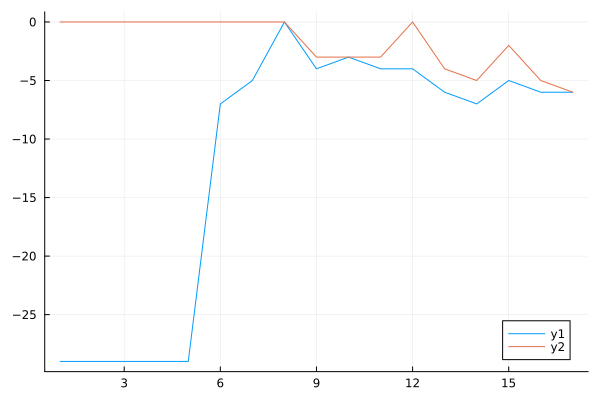

In [42]:
plot(stored_lb)
plot!(stored_ub)

In [71]:
reduced_cost.(x)

10-element Vector{Float64}:
 2.5
 0.0
 2.0
 2.0
 0.0
 0.0
 1.5
 1.0
 4.0
 0.0

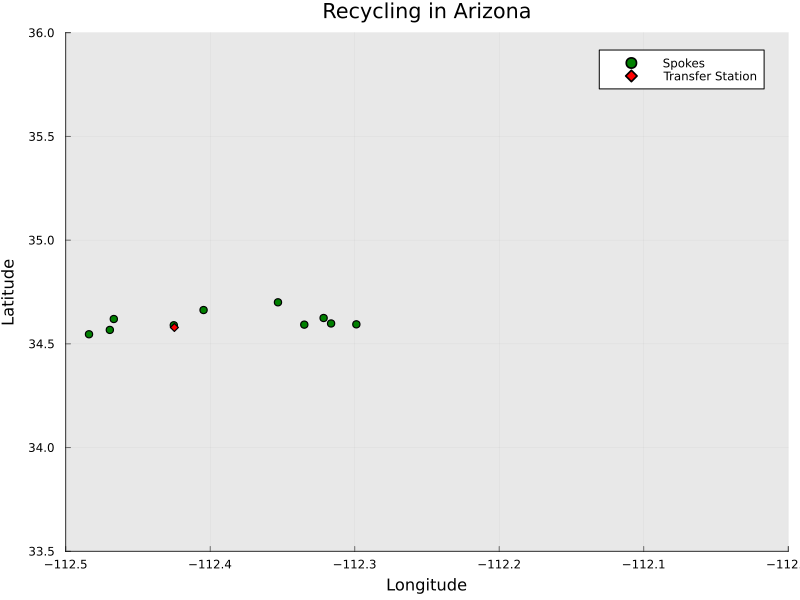

In [15]:
geojson = JSON.parsefile("arizona.json")
coordinates = geojson["geometry"]["coordinates"][1]
longitudes = [coord[1] for coord in coordinates]
latitudes = [coord[2] for coord in coordinates]
zip_data = CSV.File("Spokes.csv")
TS_data =  CSV.File("TS.csv")
MRF_data = CSV.File("MRF.csv")
EM_data = CSV.File("EM.csv")
az_zip_data = filter(x -> x.state == "AZ", zip_data)
spoke_latitudes = [row.latitude for row in zip_data]
spoke_longitudes = [row.longitude for row in zip_data]
TS_latitudes = [row.latitude for row in TS_data]
TS_longitudes = [row.longitude for row in TS_data]
MRF_latitudes = [row.latitude for row in MRF_data]
MRF_longitudes = [row.longitude for row in MRF_data]
EM_latitudes = [row.latitude for row in EM_data]
EM_longitudes = [row.longitude for row in EM_data]
plot(longitudes, latitudes, fillrange=0, linewidth=5, label = false, color=:lightgrey, fillalpha=0.5, yrange=(31, 38), size=(800, 600))
title!("Recycling in Arizona")
xlabel!("Longitude")
ylabel!("Latitude")
scatter!(spoke_longitudes, spoke_latitudes, label="Spokes", color=:green, marker=:circle, markersize=4, legend=:topright)
scatter!(TS_longitudes, TS_latitudes, label="Transfer Station", color=:red, marker=:diamond, markersize=4, legend=:topright)
xlims!(-112.5, -112.0)  # Adjust longitude range for zoom
ylims!(33.5, 36)